<div class="alert alert-danger" role="alert">
<h1 align="center"><font size = 14>Machine Learning Project 3</font></h1>
<h4 align="center">Decision Trees, Ensembles, Clustering, and Dimensionality Reduction<h4>
<h3 align="center">Armin Amani</h3>

<div class="alert alert-danger" role="alert">
📤 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, load_diabetes, load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier

from scipy.cluster.hierarchy import linkage, dendrogram


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

print("Global settings are defined successfully.")
print("RANDOM_STATE =", RANDOM_STATE)

Global settings are defined successfully.
RANDOM_STATE = 42


<div class="alert alert-danger" role="alert"> 
💾 Load and Read Dataset

In [3]:
# Digits Dataset
digits = load_digits()

X_digits = digits.data
y_digits = digits.target
digits_images = digits.images

In [4]:
digits_feature_names = [f"pixel_{i}" for i in range(X_digits.shape[1])]

df_digits = pd.DataFrame(X_digits, columns=digits_feature_names)
df_digits["target"] = y_digits

In [5]:
# Diabetes Dataset
diabetes = load_diabetes()

X_diabetes = diabetes.data
y_diabetes = diabetes.target

In [6]:
df_diabetes = pd.DataFrame(X_diabetes, columns=diabetes.feature_names)
df_diabetes["target"] = y_diabetes

In [7]:
# Iris Dataset
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

In [8]:
df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris["target"] = y_iris
df_iris["species"] = df_iris["target"].map(
    {i: name for i, name in enumerate(iris.target_names)}
)

In [9]:
# Quick overview of all datasets

Overview_of_Datasets = pd.DataFrame({
    "Dataset": ["Digits", "Diabetes", "Iris"],
    "Task Type": ["Classification / Dimensionality Reduction", "Regression", "Clustering"],
    "Number of Samples": [X_digits.shape[0], X_diabetes.shape[0], X_iris.shape[0]],
    "Number of Features": [X_digits.shape[1], X_diabetes.shape[1], X_iris.shape[1]],
    "Target / Label": [
        "Digit class: 0-9",
        "Disease progression",
        "Species label used only for validation"
    ]
})

Overview_of_Datasets

,Dataset,Task Type,Number of Samples,Number of Features,Target / Label
0,Digits,Classification / Dimensionality Reduction,1797,64,Digit class: 0-9
1,Diabetes,Regression,442,10,Disease progression
2,Iris,Clustering,150,4,Species label used only for validation


In [10]:
print("Digits dataset:")
display(df_digits.head())

Digits dataset:


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [11]:
df_digits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_0   1797 non-null   float64
 1   pixel_1   1797 non-null   float64
 2   pixel_2   1797 non-null   float64
 3   pixel_3   1797 non-null   float64
 4   pixel_4   1797 non-null   float64
 5   pixel_5   1797 non-null   float64
 6   pixel_6   1797 non-null   float64
 7   pixel_7   1797 non-null   float64
 8   pixel_8   1797 non-null   float64
 9   pixel_9   1797 non-null   float64
 10  pixel_10  1797 non-null   float64
 11  pixel_11  1797 non-null   float64
 12  pixel_12  1797 non-null   float64
 13  pixel_13  1797 non-null   float64
 14  pixel_14  1797 non-null   float64
 15  pixel_15  1797 non-null   float64
 16  pixel_16  1797 non-null   float64
 17  pixel_17  1797 non-null   float64
 18  pixel_18  1797 non-null   float64
 19  pixel_19  1797 non-null   float64
 20  pixel_20  1797 non-null   floa

In [12]:
print("Diabetes dataset:")
display(df_diabetes.head())

Diabetes dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [13]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [14]:
print("Iris dataset:")
display(df_iris.head())

Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [15]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


<div class="alert alert-danger" role="alert"> 
🔎 Part 1: Decision Trees

* **1a. Decision Tree Classifier - Digits Dataset**

* **Load the Digits data (sklearn.datasets.load_digits). It contains 1797 samples of 8 × 8
pixel images (flattened to 64 features) and integer labels 0-9.**

In [16]:
digits = load_digits()

X_digits = digits.data

y_digits = digits.target

digits_images = digits.images

digits_target_names = digits.target_names

digits_feature_names = [
    f"pixel_{row}_{col}"
    for row in range(8)
    for col in range(8)
]

# Create a DataFrame for easier inspection and EDA
df_digits = pd.DataFrame(X_digits, columns=digits_feature_names)
df_digits["target"] = y_digits

# Display basic information
print("Digits dataset loaded successfully.")
print("shape of Feature matrix is:", X_digits.shape)
print("shape of Image array is:", digits_images.shape)
print("shape of Target vector is:", y_digits.shape)
print("Target classes are:", digits_target_names)

Digits dataset loaded successfully.
shape of Feature matrix is: (1797, 64)
shape of Image array is: (1797, 8, 8)
shape of Target vector is: (1797,)
Target classes are: [0 1 2 3 4 5 6 7 8 9]


* **Perform a brief EDA: class distribution (bar plot), pixel intensity statistics, sample images
for each digit.**

In [17]:
print("Number of unique classes are:", len(np.unique(y_digits)))

# Check missing values
missing_values = df_digits.isnull().sum().sum()
print("Total missing values:", missing_values)

Number of unique classes are: 10
Total missing values: 0


In [18]:
# Class distribution

class_counts = pd.Series(y_digits).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Digit Class": class_counts.index,
    "Number of Samples": class_counts.values,
    "Percentage (%)": np.round(100 * class_counts.values / len(y_digits), 2)
})

display(class_distribution)

,Digit Class,Number of Samples,Percentage (%)
0,0,178,9.91
1,1,182,10.13
2,2,177,9.85
3,3,183,10.18
4,4,181,10.07
5,5,182,10.13
6,6,181,10.07
7,7,179,9.96
8,8,174,9.68
9,9,180,10.02


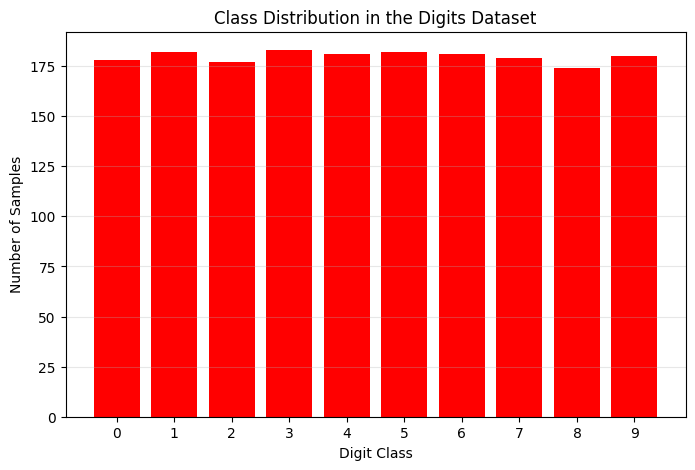

In [19]:
# Class distribution bar plot

plt.figure(figsize=(8, 5))

plt.bar(
    class_distribution["Digit Class"],
    class_distribution["Number of Samples"],
    color='r'
)

plt.title("Class Distribution in the Digits Dataset")
plt.xlabel("Digit Class")
plt.ylabel("Number of Samples")
plt.xticks(class_distribution["Digit Class"])
plt.grid(axis="y", alpha=0.3)

plt.show()

In [20]:
# Pixel intensity statistics

pixel_values = X_digits.flatten()

pixel_intensity_stats = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Standard Deviation",
        "Median",
        "25th Percentile",
        "75th Percentile"
    ],
    "Value": [
        np.min(pixel_values),
        np.max(pixel_values),
        np.mean(pixel_values),
        np.std(pixel_values),
        np.median(pixel_values),
        np.percentile(pixel_values, 25),
        np.percentile(pixel_values, 75)
    ]
})

display(pixel_intensity_stats)

,Statistic,Value
0,Minimum,0.000000
1,Maximum,16.000000
2,Mean,4.884165
3,Standard Deviation,6.016788
4,Median,1.000000
5,25th Percentile,0.000000
6,75th Percentile,10.000000


* **Most pixel intensity values are low because a large part of each 8×8 image corresponds to the dark background. The median intensity is 1, while the mean is higher, about 4.88, because the bright stroke pixels of the handwritten digits increase the average intensity.**

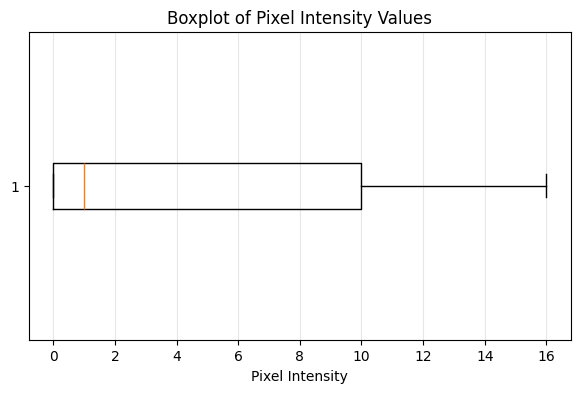

In [21]:
# Pixel intensity boxplot

plt.figure(figsize=(7, 4))

plt.boxplot(
    pixel_values,
    vert=False
)

plt.title("Boxplot of Pixel Intensity Values")
plt.xlabel("Pixel Intensity")
plt.grid(axis="x", alpha=0.3)

plt.show()

* **The boxplot shows that the first quartile is 0, the median is 1, and the third quartile is 10. This indicates that many pixels are close to the background intensity, while a smaller portion of pixels represents brighter digit strokes. Since the maximum value is 16 and still lies within the boxplot whisker range, no extreme outliers are observed in the global pixel intensity distribution.**

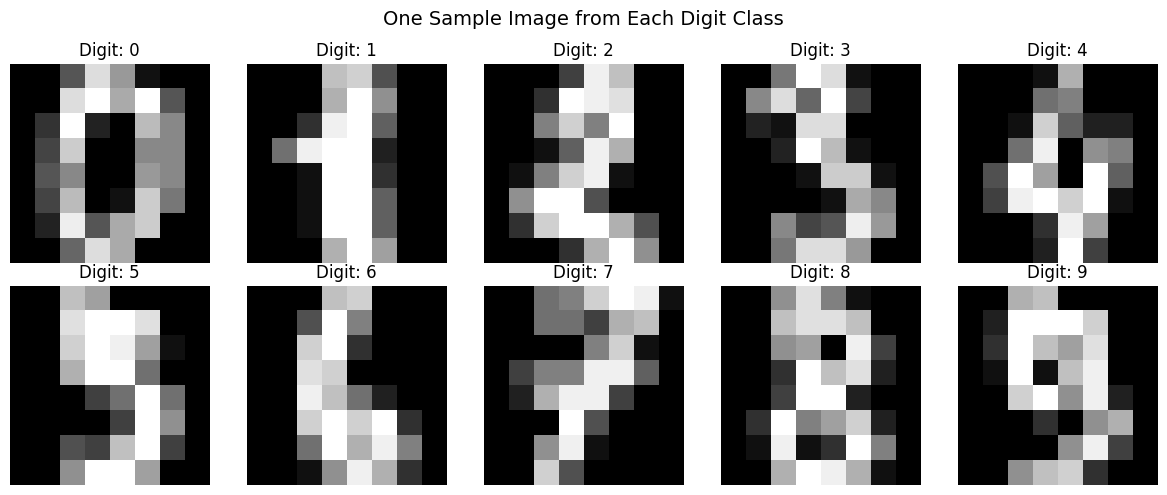

In [22]:
# Display one representative sample image for each digit

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    sample_index = np.where(y_digits == digit)[0][0]
    
    axes[digit].imshow(digits_images[sample_index], cmap="gray")
    axes[digit].set_title(f"Digit: {digit}")
    axes[digit].axis("off")

plt.suptitle("One Sample Image from Each Digit Class", fontsize=14)
plt.tight_layout()
plt.show()

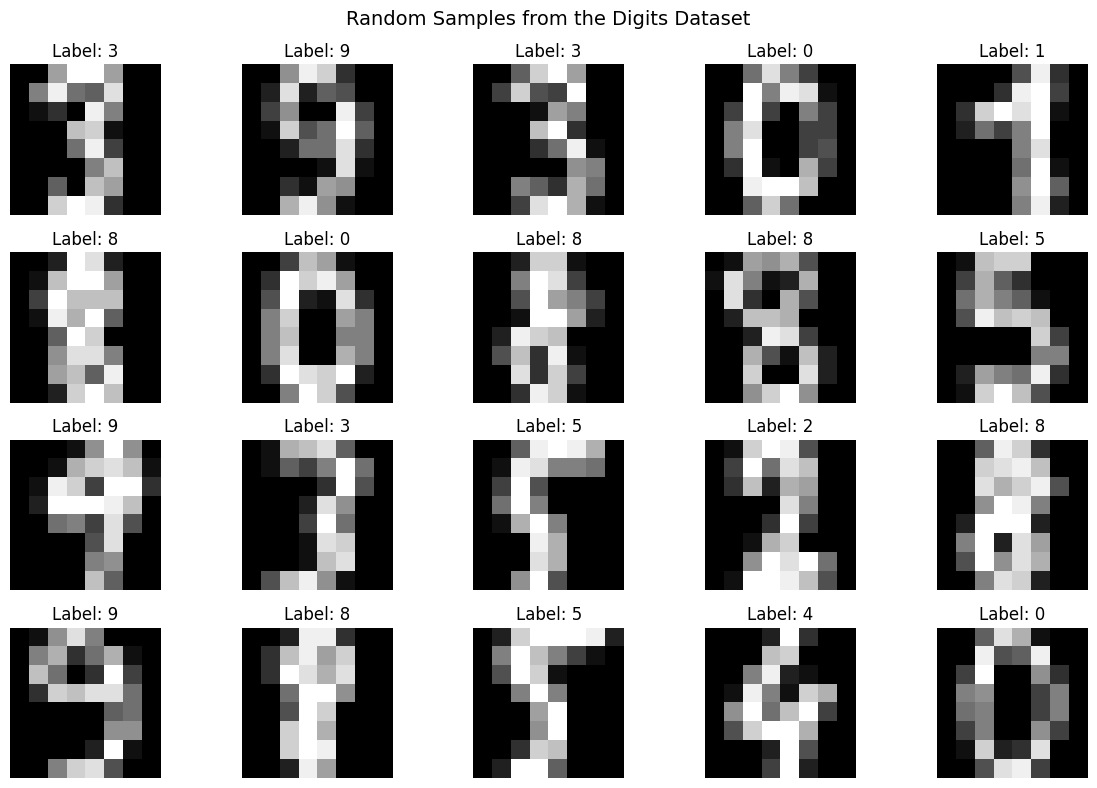

In [23]:
# Display random digit samples

rng = np.random.default_rng(RANDOM_STATE)
random_indices = rng.choice(len(digits_images), size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(12, 8))
axes = axes.ravel()

for ax, idx in zip(axes, random_indices):
    ax.imshow(digits_images[idx], cmap="gray")
    ax.set_title(f"Label: {y_digits[idx]}")
    ax.axis("off")

plt.suptitle("Random Samples from the Digits Dataset", fontsize=14)
plt.tight_layout()
plt.show()

* **Split into training (80%) and test (20%) sets. Scaling is not required for trees, but you may
apply StandardScaler for consistency (feature importance interpretation on pixel values
remains intuitive).**

In [24]:
# Train/Test split for Digits classification

# Safety definitions in case the global settings cell has not been executed
if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

if "TEST_SIZE" not in globals():
    TEST_SIZE = 0.20

X_digits_train, X_digits_test, y_digits_train, y_digits_test = train_test_split(
    X_digits,
    y_digits,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_digits
)

print("Train/Test split completed successfully.")
print("shape of X_digits_train is:", X_digits_train.shape)
print("shape of X_digits_test is:", X_digits_test.shape)
print("shape of y_digits_train is:", y_digits_train.shape)
print("shape of y_digits_test is:", y_digits_test.shape)

Train/Test split completed successfully.
shape of X_digits_train is: (1437, 64)
shape of X_digits_test is: (360, 64)
shape of y_digits_train is: (1437,)
shape of y_digits_test is: (360,)


In [25]:
# Checking class distribution after splitting

train_class_counts = pd.Series(y_digits_train).value_counts().sort_index()
test_class_counts = pd.Series(y_digits_test).value_counts().sort_index()

split_distribution = pd.DataFrame({
    "Digit Class": np.arange(10),
    "Train Count": train_class_counts.values,
    "Test Count": test_class_counts.values,
    "Train Percentage (%)": np.round(100 * train_class_counts.values / len(y_digits_train), 2),
    "Test Percentage (%)": np.round(100 * test_class_counts.values / len(y_digits_test), 2)
})

display(split_distribution)

,Digit Class,Train Count,Test Count,Train Percentage (%),Test Percentage (%)
0,0,142,36,9.88,10.00
1,1,146,36,10.16,10.00
2,2,142,35,9.88,9.72
3,3,146,37,10.16,10.28
4,4,145,36,10.09,10.00
5,5,145,37,10.09,10.28
6,6,145,36,10.09,10.00
7,7,143,36,9.95,10.00
8,8,139,35,9.67,9.72
9,9,144,36,10.02,10.00


* **Train a DecisionTreeClassifier. Use GridSearchCV (5-fold, stratified) to tune at least
max_depth (range 1-20), min_samples_split (2, 5, 10), and criterion (gini, entropy).**

In [26]:
# Define stratified cross-validation

DT_stratified_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Stratified cross-validation is ready.")
print("Number of folds are:", CV_FOLDS)

Stratified cross-validation is ready.
Number of folds are: 5


In [27]:
#  Define Decision Tree model and parameter grid

DT_classifier = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

DT_param_grid = {
    "max_depth": list(range(1, 21)),
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

num_combinations = (
    len(DT_param_grid["max_depth"])
    * len(DT_param_grid["min_samples_split"])
    * len(DT_param_grid["criterion"])
)

print("Decision Tree parameter grid is defined.")
print("Number of hyperparameter combinations are:", num_combinations)
print("Total number of model fits are:", num_combinations * CV_FOLDS)

Decision Tree parameter grid is defined.
Number of hyperparameter combinations are: 120
Total number of model fits are: 600


In [28]:
# Hyperparameter tuning with GridSearchCV

DT_grid_search = GridSearchCV(
    estimator=DT_classifier,
    param_grid=DT_param_grid,
    scoring="accuracy",
    cv=DT_stratified_cv,
    n_jobs=-1,
    return_train_score=True
)

# Fit GridSearchCV only on the training data
DT_grid_search.fit(X_digits_train, y_digits_train)

print("GridSearchCV completed successfully.")
print("Best hyperparameters are:", DT_grid_search.best_params_)
print("Best cross-validation accuracy is:", DT_grid_search.best_score_)

GridSearchCV completed successfully.
Best hyperparameters are: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 5}
Best cross-validation accuracy is: 0.8538593689508323


In [29]:
best_DT_classifier = DT_grid_search.best_estimator_

print("Best Decision Tree Classifier:")
print(best_DT_classifier)

Best Decision Tree Classifier:
DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_split=5,
                       random_state=42)


In [30]:
# Cross-validation results table

DT_cv_results = pd.DataFrame(DT_grid_search.cv_results_)

# Select the most important columns
DT_cv_summary = DT_cv_results[
    [
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

DT_cv_summary = DT_cv_summary.sort_values("rank_test_score")

display(DT_cv_summary.head(10))

,param_criterion,param_max_depth,param_min_samples_split,mean_train_score,mean_test_score,std_test_score,rank_test_score
82,entropy,8,5,0.965381,0.853859,0.022803,1
98,entropy,13,10,0.949897,0.853160,0.016450,2
107,entropy,16,10,0.949897,0.853160,0.016450,2
101,entropy,14,10,0.949897,0.853160,0.016450,2
110,entropy,17,10,0.949897,0.853160,0.016450,2
119,entropy,20,10,0.949897,0.853160,0.016450,2
116,entropy,19,10,0.949897,0.853160,0.016450,2
104,entropy,15,10,0.949897,0.853160,0.016450,2
92,entropy,11,10,0.949897,0.853160,0.016450,2
95,entropy,12,10,0.949897,0.853160,0.016450,2


In [31]:
best_DT_summary = pd.DataFrame({
    "Item": [
        "Best criterion",
        "Best max_depth",
        "Best min_samples_split",
        "Best mean CV accuracy",
        "Number of CV folds",
        "Scoring metric"
    ],
    "Value": [
        DT_grid_search.best_params_["criterion"],
        DT_grid_search.best_params_["max_depth"],
        DT_grid_search.best_params_["min_samples_split"],
        round(DT_grid_search.best_score_, 4),
        CV_FOLDS,
        "Accuracy"
    ]
})

display(best_DT_summary)

,Item,Value
0,Best criterion,entropy
1,Best max_depth,8
2,Best min_samples_split,5
3,Best mean CV accuracy,0.8539
4,Number of CV folds,5
5,Scoring metric,Accuracy


* **Evaluate on the test set: accuracy, confusion matrix (10 × 10), precision, recall, and F1-score
(macro-averaged). Display the confusion matrix as a heatmap.**

In [32]:
# Test set prediction

y_digits_pred_DT = best_DT_classifier.predict(X_digits_test)

print("Prediction on the test set completed successfully.")


# Evaluation metrics

DT_test_accuracy = metrics.accuracy_score(y_digits_test, y_digits_pred_DT)

DT_test_precision_macro = metrics.precision_score(
    y_digits_test,
    y_digits_pred_DT,
    average="macro",
    zero_division=0
)

DT_test_recall_macro = metrics.recall_score(
    y_digits_test,
    y_digits_pred_DT,
    average="macro",
    zero_division=0
)

DT_test_f1_macro = metrics.f1_score(
    y_digits_test,
    y_digits_pred_DT,
    average="macro",
    zero_division=0
)

DT_test_metrics = pd.DataFrame({
    "Model": ["Decision Tree Classifier"],
    "Accuracy": [DT_test_accuracy],
    "Macro Precision": [DT_test_precision_macro],
    "Macro Recall": [DT_test_recall_macro],
    "Macro F1-score": [DT_test_f1_macro]
})

display(DT_test_metrics)

Prediction on the test set completed successfully.


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,Decision Tree Classifier,0.85,0.854435,0.849794,0.850841


In [33]:
# classification report

print("Classification Report - Decision Tree Classifier")
print(
    metrics.classification_report(
        y_digits_test,
        y_digits_pred_DT,
        target_names=[str(i) for i in range(10)],
        zero_division=0
    )
)

Classification Report - Decision Tree Classifier
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        36
           1       0.73      0.83      0.78        36
           2       0.94      0.89      0.91        35
           3       0.89      0.84      0.86        37
           4       0.85      0.94      0.89        36
           5       0.86      0.86      0.86        37
           6       0.89      0.89      0.89        36
           7       0.86      0.83      0.85        36
           8       0.74      0.74      0.74        35
           9       0.78      0.81      0.79        36

    accuracy                           0.85       360
   macro avg       0.85      0.85      0.85       360
weighted avg       0.85      0.85      0.85       360



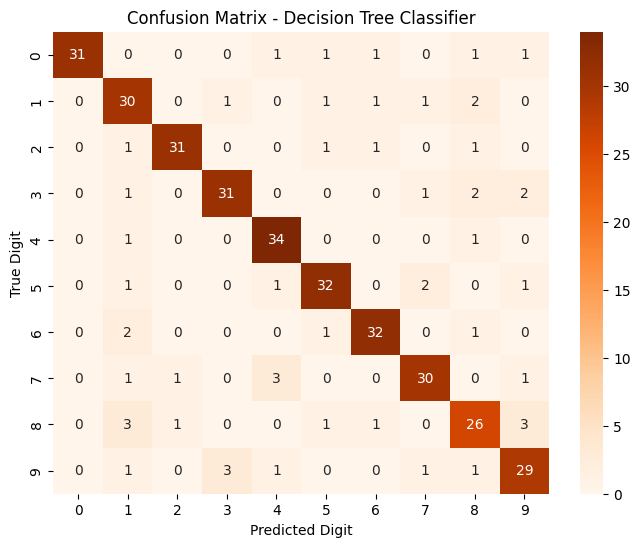

In [34]:
# Confusion Matrix - Decision Tree Classifier

DT_conf_matrix = metrics.confusion_matrix(y_digits_test, y_digits_pred_DT)

plt.figure(figsize=(8, 6))

sns.heatmap(
    DT_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

* **Plot feature importance and discuss which pixel positions (reshape to 8 × 8 for visualization)
are most informative for digit recognition.**

In [35]:
# Extract feature importances

DT_feature_importances = best_DT_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature Index": np.arange(len(DT_feature_importances)),
    "Pixel Row": np.arange(len(DT_feature_importances)) // 8,
    "Pixel Column": np.arange(len(DT_feature_importances)) % 8,
    "Importance": DT_feature_importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_df.head(15))

,Feature Index,Pixel Row,Pixel Column,Importance
33,33,4,1,0.145329
43,43,5,3,0.099376
36,36,4,4,0.077028
61,61,7,5,0.075419
26,26,3,2,0.062879
21,21,2,5,0.060971
54,54,6,6,0.052159
10,10,1,2,0.041178
38,38,4,6,0.033237
13,13,1,5,0.032568


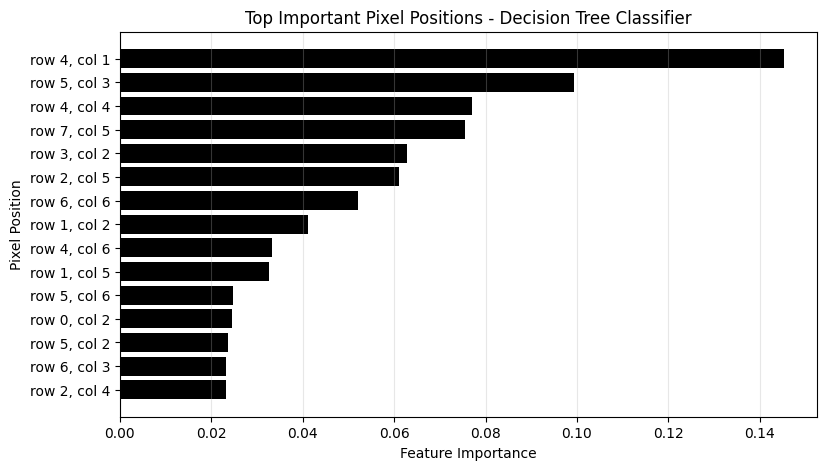

In [36]:
# Top important pixel positions

top_n_pixels = 15
top_pixels = feature_importance_df.head(top_n_pixels).copy()

top_pixels["Pixel Position"] = (
    "row " + top_pixels["Pixel Row"].astype(str)
    + ", col " + top_pixels["Pixel Column"].astype(str)
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_pixels["Pixel Position"][::-1],
    top_pixels["Importance"][::-1],
    color='k'
)

plt.title("Top Important Pixel Positions - Decision Tree Classifier")
plt.xlabel("Feature Importance")
plt.ylabel("Pixel Position")
plt.grid(axis="x", alpha=0.3)

plt.show()

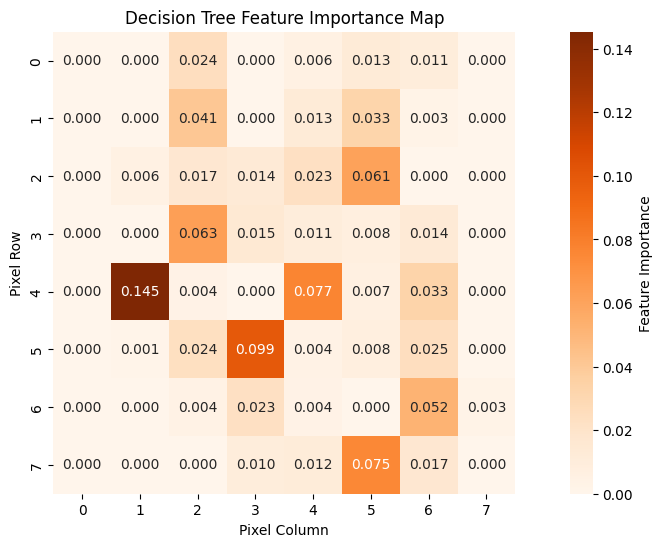

In [37]:
# Feature importance heatmap reshaped to 8x8

importance_image = DT_feature_importances.reshape(8, 8)

plt.figure(figsize=(14, 6))

sns.heatmap(
    importance_image,
    annot=True,
    fmt=".3f",
    cmap="Oranges",
    square=True,
    cbar_kws={"label": "Feature Importance"}
)

plt.title("Decision Tree Feature Importance Map")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.show()

* **The feature importance map shows which pixel positions contributed most strongly to the Decision Tree's classification decisions.**

* **Pixels with higher importance values are usually located in regions where handwritten digits differ most from each other.  
For example, central and stroke-related regions are often more informative than corner pixels, because corner pixels frequently belong to the background.**

* **Plot cross-validation accuracy versus max_depth to illustrate overfitting/underfitting.**

In [38]:
# Prepare CV results by max_depth

DT_cv_results = pd.DataFrame(DT_grid_search.cv_results_)

best_depth_indices = DT_cv_results.groupby("param_max_depth")["mean_test_score"].idxmax()

DT_depth_results = DT_cv_results.loc[
    best_depth_indices,
    [
        "param_max_depth",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "param_criterion",
        "param_min_samples_split"
    ]
].copy()

DT_depth_results["param_max_depth"] = DT_depth_results["param_max_depth"].astype(int)

DT_depth_results = DT_depth_results.sort_values("param_max_depth")

display(DT_depth_results)

,param_max_depth,mean_train_score,mean_test_score,std_test_score,param_criterion,param_min_samples_split
0,1,0.199199,0.198326,0.002806,gini,2
63,2,0.364298,0.350041,0.014319,entropy,2
66,3,0.563330,0.533067,0.020031,entropy,2
69,4,0.707036,0.661784,0.020146,entropy,2
74,5,0.815595,0.769619,0.035560,entropy,10
76,6,0.895446,0.819057,0.020923,entropy,5
78,7,0.947638,0.841333,0.014580,entropy,2
82,8,0.965381,0.853859,0.022803,entropy,5
86,9,0.949028,0.851766,0.016788,entropy,10
89,10,0.949897,0.853160,0.016450,entropy,10


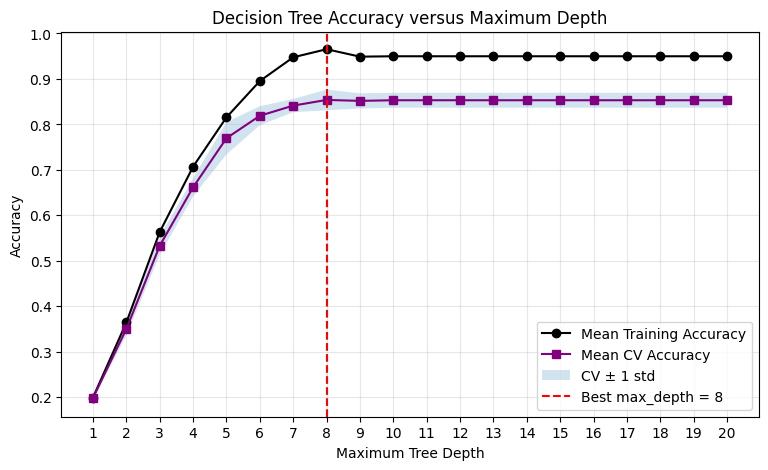

In [39]:
# Plot train and cross-validation accuracy versus max_depth

best_depth = DT_grid_search.best_params_["max_depth"]

plt.figure(figsize=(9, 5))

plt.plot(
    DT_depth_results["param_max_depth"],
    DT_depth_results["mean_train_score"],
    marker="o",
    label="Mean Training Accuracy",
    color="k"
)

plt.plot(
    DT_depth_results["param_max_depth"],
    DT_depth_results["mean_test_score"],
    marker="s",
    label="Mean CV Accuracy",
    color="purple"
)

plt.fill_between(
    DT_depth_results["param_max_depth"],
    DT_depth_results["mean_test_score"] - DT_depth_results["std_test_score"],
    DT_depth_results["mean_test_score"] + DT_depth_results["std_test_score"],
    alpha=0.2,
    label="CV ± 1 std"
)

plt.axvline(
    x=best_depth,
    linestyle="--",
    label=f"Best max_depth = {best_depth}",
    color="r"
)

plt.title("Decision Tree Accuracy versus Maximum Depth")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation of Accuracy versus Tree Depth

* **The plot shows how the Decision Tree performance changes as `max_depth` increases.**

* **At small depths, both training and cross-validation accuracy are low, which indicates **underfitting**. The tree is too simple to capture the digit patterns.**

* **As the depth increases, both accuracies improve. The best cross-validation accuracy occurs around `max_depth = 8`, which gives a good balance between model complexity and generalization.**

* **After this point, the training accuracy remains high, but the cross-validation accuracy does not improve noticeably. This suggests that deeper trees add complexity and may increase the risk of **overfitting** without improving test generalization.**

In [40]:
# Final compact summary for First Part

DT_part1a_summary = pd.DataFrame({
    "Item": [
        "Best criterion",
        "Best max_depth",
        "Best min_samples_split",
        "Best CV accuracy",
        "Test accuracy",
        "Test macro precision",
        "Test macro recall",
        "Test macro F1-score"
    ],
    "Value": [
        DT_grid_search.best_params_["criterion"],
        DT_grid_search.best_params_["max_depth"],
        DT_grid_search.best_params_["min_samples_split"],
        round(DT_grid_search.best_score_, 4),
        round(DT_test_accuracy, 4),
        round(DT_test_precision_macro, 4),
        round(DT_test_recall_macro, 4),
        round(DT_test_f1_macro, 4)
    ]
})

display(DT_part1a_summary)

,Item,Value
0,Best criterion,entropy
1,Best max_depth,8
2,Best min_samples_split,5
3,Best CV accuracy,0.8539
4,Test accuracy,0.85
5,Test macro precision,0.8544
6,Test macro recall,0.8498
7,Test macro F1-score,0.8508


* **1b. Decision Tree Regressor - Diabetes Dataset**

* **Load the Diabetes data (sklearn.datasets.load_diabetes).**

In [41]:
# Load the Diabetes Dataset

diabetes = load_diabetes()

X_diabetes = diabetes.data
y_diabetes = diabetes.target
diabetes_feature_names = diabetes.feature_names

df_diabetes = pd.DataFrame(X_diabetes, columns=diabetes_feature_names)
df_diabetes["target"] = y_diabetes

print("Diabetes dataset loaded successfully.")
print("Feature matrix shape:", X_diabetes.shape)
print("Target vector shape:", y_diabetes.shape)
print("Feature names:", diabetes_feature_names)

display(df_diabetes.head())

Diabetes dataset loaded successfully.
Feature matrix shape: (442, 10)
Target vector shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [42]:
diabetes_overview = pd.DataFrame({
    "Property": [
        "Number of samples",
        "Number of features",
        "Target type",
        "Task type"
    ],
    "Value": [
        X_diabetes.shape[0],
        X_diabetes.shape[1],
        "Continuous disease progression score",
        "Regression"
    ]
})

display(diabetes_overview)

,Property,Value
0,Number of samples,442
1,Number of features,10
2,Target type,Continuous disease progression score
3,Task type,Regression


* **Split and scale the features (scaling is irrelevant for trees but harmless).**

In [43]:
# Train/Test Split and Feature Scaling

# Safety definitions
if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

if "TEST_SIZE" not in globals():
    TEST_SIZE = 0.20

# Train/test split
X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Train/Test split completed successfully.")
print("X_diabetes_train shape:", X_diabetes_train.shape)
print("X_diabetes_test shape:", X_diabetes_test.shape)
print("y_diabetes_train shape:", y_diabetes_train.shape)
print("y_diabetes_test shape:", y_diabetes_test.shape)

Train/Test split completed successfully.
X_diabetes_train shape: (353, 10)
X_diabetes_test shape: (89, 10)
y_diabetes_train shape: (353,)
y_diabetes_test shape: (89,)


In [44]:
# Scaling
diabetes_scaler = StandardScaler()

X_diabetes_train_scaled = diabetes_scaler.fit_transform(X_diabetes_train)
X_diabetes_test_scaled = diabetes_scaler.transform(X_diabetes_test)

print("Feature scaling completed successfully.")
print("Training feature mean after scaling is:", np.round(X_diabetes_train_scaled.mean(axis=0), 4))
print("Training feature std after scaling is:", np.round(X_diabetes_train_scaled.std(axis=0), 4))

Feature scaling completed successfully.
Training feature mean after scaling is: [ 0.  0. -0.  0. -0. -0.  0.  0.  0. -0.]
Training feature std after scaling is: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


* **Tune a DecisionTreeRegressor with GridSearchCV over max_depth (1-10), min_samples_split,
and criterion (squared_error, absolute_error).**

In [45]:
# Decision Tree Regressor Hyperparameter Tuning

# Safety definition
if "CV_FOLDS" not in globals():
    CV_FOLDS = 5

DT_reg_cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Base Decision Tree Regressor
DT_regressor = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

DT_reg_param_grid = {
    "max_depth": list(range(1, 11)),
    "min_samples_split": [2, 5, 10],
    "criterion": ["squared_error", "absolute_error"]
}

num_reg_combinations = (
    len(DT_reg_param_grid["max_depth"])
    * len(DT_reg_param_grid["min_samples_split"])
    * len(DT_reg_param_grid["criterion"])
)

print("Number of hyperparameter combinations are:", num_reg_combinations)
print("Total number of model fits are:", num_reg_combinations * CV_FOLDS)

Number of hyperparameter combinations are: 60
Total number of model fits are: 300


In [46]:
# GridSearchCV
DT_reg_grid_search = GridSearchCV(
    estimator=DT_regressor,
    param_grid=DT_reg_param_grid,
    scoring="r2",
    cv=DT_reg_cv,
    n_jobs=-1,
    return_train_score=True
)

# Fit only on the training data
DT_reg_grid_search.fit(X_diabetes_train_scaled, y_diabetes_train)

print("GridSearchCV completed successfully.")
print("Best hyperparameters are:", DT_reg_grid_search.best_params_)
print("Best mean CV R2 score is:", DT_reg_grid_search.best_score_)

GridSearchCV completed successfully.
Best hyperparameters are: {'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 2}
Best mean CV R2 score is: 0.32563252296725764


In [47]:
# Store best model
best_DT_regressor = DT_reg_grid_search.best_estimator_

# Display top CV results
DT_reg_cv_results = pd.DataFrame(DT_reg_grid_search.cv_results_)

DT_reg_cv_summary = DT_reg_cv_results[
    [
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

DT_reg_cv_summary = DT_reg_cv_summary.sort_values("rank_test_score")

display(DT_reg_cv_summary.head(10))

,param_criterion,param_max_depth,param_min_samples_split,mean_train_score,mean_test_score,std_test_score,rank_test_score
3,squared_error,2,2,0.456085,0.325633,0.072204,1
4,squared_error,2,5,0.456085,0.325633,0.072204,1
5,squared_error,2,10,0.456085,0.325633,0.072204,1
6,squared_error,3,2,0.539006,0.284580,0.110337,4
7,squared_error,3,5,0.539006,0.284580,0.110337,4
8,squared_error,3,10,0.539006,0.284580,0.110337,4
34,absolute_error,2,5,0.430921,0.262592,0.159395,7
33,absolute_error,2,2,0.430921,0.262592,0.159395,7
35,absolute_error,2,10,0.430921,0.262592,0.159395,7
11,squared_error,4,10,0.604364,0.245133,0.096755,10


* **Evaluate on the test set: MSE, RMSE, and R2.**

In [48]:
# Test Set Evaluation

y_diabetes_pred_DT = best_DT_regressor.predict(X_diabetes_test_scaled)

# Regression metrics
DT_reg_test_MSE = metrics.mean_squared_error(y_diabetes_test, y_diabetes_pred_DT)
DT_reg_test_RMSE = np.sqrt(DT_reg_test_MSE)
DT_reg_test_r2 = metrics.r2_score(y_diabetes_test, y_diabetes_pred_DT)

DT_reg_train_pred = best_DT_regressor.predict(X_diabetes_train_scaled)
DT_reg_train_MSE = metrics.mean_squared_error(y_diabetes_train, DT_reg_train_pred)
DT_reg_train_RMSE = np.sqrt(DT_reg_train_MSE)
DT_reg_train_r2 = metrics.r2_score(y_diabetes_train, DT_reg_train_pred)

DT_reg_metrics = pd.DataFrame({
    "Model": ["Decision Tree Regressor"],
    "Train MSE": [DT_reg_train_MSE],
    "Train RMSE": [DT_reg_train_RMSE],
    "Train R2": [DT_reg_train_r2],
    "Test MSE": [DT_reg_test_MSE],
    "Test RMSE": [DT_reg_test_RMSE],
    "Test R2": [DT_reg_test_r2]
})

display(DT_reg_metrics)

print("Test MSE is:", round(DT_reg_test_MSE, 4))
print("Test RMSE is:", round(DT_reg_test_RMSE, 4))
print("Test R2 is:", round(DT_reg_test_r2, 4))

,Model,Train MSE,Train RMSE,Train R2,Test MSE,Test RMSE,Test R2
0,Decision Tree Regressor,3358.625381,57.953649,0.447267,3735.499618,61.118734,0.294943


Test MSE is: 3735.4996
Test RMSE is: 61.1187
Test R2 is: 0.2949


* **Plot feature importance and compare with known physiological predictors.**

In [49]:
# Feature Importance Analysis

DT_reg_feature_importances = best_DT_regressor.feature_importances_

diabetes_feature_importance_df = pd.DataFrame({
    "Feature": diabetes_feature_names,
    "Importance": DT_reg_feature_importances
}).sort_values(
    by="Importance",
    ascending=False
)

display(diabetes_feature_importance_df)

,Feature,Importance
2,bmi,0.822417
8,s5,0.177583
1,sex,0.000000
0,age,0.000000
4,s1,0.000000
3,bp,0.000000
5,s2,0.000000
6,s3,0.000000
7,s4,0.000000
9,s6,0.000000


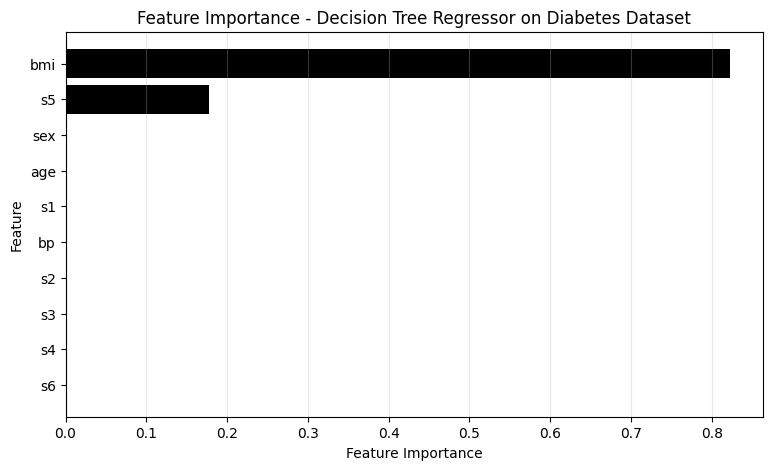

In [50]:
plt.figure(figsize=(9, 5))

plt.barh(
    diabetes_feature_importance_df["Feature"][::-1],
    diabetes_feature_importance_df["Importance"][::-1],
    color='k'
)

plt.title("Feature Importance - Decision Tree Regressor on Diabetes Dataset")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [51]:
# Add physiological descriptions for interpretation
diabetes_feature_description = pd.DataFrame({
    "Feature": ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"],
    "Description": [
        "Age",
        "Sex",
        "Body mass index",
        "Average blood pressure",
        "Total serum cholesterol",
        "Low-density lipoproteins",
        "High-density lipoproteins",
        "Total cholesterol / HDL ratio",
        "Log of serum triglycerides level",
        "Blood sugar level"
    ]
})

diabetes_feature_interpretation = diabetes_feature_importance_df.merge(
    diabetes_feature_description,
    on="Feature",
    how="left"
)

display(diabetes_feature_interpretation)

,Feature,Importance,Description
0,bmi,0.822417,Body mass index
1,s5,0.177583,Log of serum triglycerides level
2,sex,0.000000,Sex
3,age,0.000000,Age
4,s1,0.000000,Total serum cholesterol
5,bp,0.000000,Average blood pressure
6,s2,0.000000,Low-density lipoproteins
7,s3,0.000000,High-density lipoproteins
8,s4,0.000000,Total cholesterol / HDL ratio
9,s6,0.000000,Blood sugar level


* **Show train vs. test R2 curves over tree depth to illustrate bias-variance trade-off.**

In [52]:
# Train vs Test R2 Curves over Tree Depth

depth_values = range(1, 11)

train_r2_scores = []
test_r2_scores = []

for depth in depth_values:
    temp_DT_regressor = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE,
        criterion=DT_reg_grid_search.best_params_["criterion"],
        min_samples_split=DT_reg_grid_search.best_params_["min_samples_split"]
    )
    
    temp_DT_regressor.fit(X_diabetes_train_scaled, y_diabetes_train)
    
    y_train_pred_depth = temp_DT_regressor.predict(X_diabetes_train_scaled)
    y_test_pred_depth = temp_DT_regressor.predict(X_diabetes_test_scaled)
    
    train_r2_scores.append(metrics.r2_score(y_diabetes_train, y_train_pred_depth))
    test_r2_scores.append(metrics.r2_score(y_diabetes_test, y_test_pred_depth))

depth_r2_df = pd.DataFrame({
    "Max Depth": list(depth_values),
    "Train R2": train_r2_scores,
    "Test R2": test_r2_scores
})

display(depth_r2_df)

,Max Depth,Train R2,Test R2
0,1,0.304309,0.130529
1,2,0.447267,0.294943
2,3,0.516977,0.329445
3,4,0.584580,0.326375
4,5,0.668606,0.334482
5,6,0.746810,0.307180
6,7,0.812596,0.191084
7,8,0.873199,0.278494
8,9,0.913516,0.225485
9,10,0.938186,0.171790


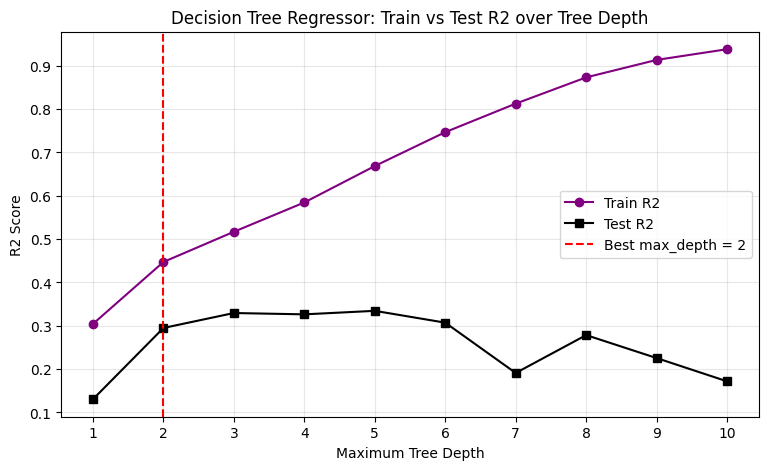

In [53]:
best_reg_depth = DT_reg_grid_search.best_params_["max_depth"]

plt.figure(figsize=(9, 5))

plt.plot(
    depth_r2_df["Max Depth"],
    depth_r2_df["Train R2"],
    marker="o",
    label="Train R2",
    color="purple"
)

plt.plot(
    depth_r2_df["Max Depth"],
    depth_r2_df["Test R2"],
    marker="s",
    label="Test R2",
    color="k"
)

plt.axvline(
    x=best_reg_depth,
    linestyle="--",
    label=f"Best max_depth = {best_reg_depth}",
    color='r'
)

plt.title("Decision Tree Regressor: Train vs Test R2 over Tree Depth")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("R2 Score")
plt.xticks(list(depth_values))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation of Train vs Test R² over Tree Depth

* **This plot shows how the Decision Tree Regressor behaves as `max_depth` increases.**

* **At small depths, the model is simple and may underfit the data. As the depth increases, the training R² continuously improves, meaning the tree fits the training data more closely.**

* **However, the test R² does not improve in the same way and even decreases for deeper trees. This growing gap between train and test performance indicates **overfitting**: the model learns training-specific patterns that do not generalize well to unseen data.**

* **The selected `max_depth = 2` represents a simpler tree with better generalization according to cross-validation.**

# 🌳 Part 1 Summary — Decision Trees

In this part, Decision Tree models were applied to both classification and regression tasks.

For the **Digits classification** task, the dataset was almost balanced across the ten digit classes. After tuning with GridSearchCV, the best Decision Tree used `entropy`, `max_depth = 8`, and `min_samples_split = 5`. The model reached about **0.85 test accuracy** and **0.85 macro F1-score**, which shows reasonable performance for a single tree model.

The feature importance results showed that central pixel regions were more useful for digit recognition than corner or background pixels. The depth curve also showed that very shallow trees underfit, while deeper trees add complexity without clear improvement after a certain point.

For the **Diabetes regression** task, the best Decision Tree Regressor used a shallow structure with `max_depth = 2`. The feature importance plot showed that **BMI** was the most important predictor, followed by **s5**. The train/test R² curve showed that deeper trees fitted the training data better but generalized worse, indicating overfitting.

**Overall, Decision Trees were easy to interpret, but their performance depended strongly on tree depth. A moderate depth worked better for digit classification, while a shallow tree was more suitable for diabetes regression.**

<div class="alert alert-danger" role="alert"> 
🔎 Part 2: Ensemble Methods

* **2a. Bagging and Random Forest - Digits Classification**

* **Bagging: Train a BaggingClassifier with a decision tree base estimator. Tune n_estimators
(e.g., 10-200). Evaluate test accuracy and confusion matrix. Compare with the single best
tree from Part 1.**

In [54]:
# Bagging Classifier - Digits Classification

# Safety definitions
if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

if "CV_FOLDS" not in globals():
    CV_FOLDS = 5

bagging_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

bagging_base_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

bagging_classifier = BaggingClassifier(
    estimator=bagging_base_tree,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Tune n_estimators (e.g., 10-200)
bagging_param_grid = {
    "n_estimators": [10, 25, 50, 100, 150, 200]
}

In [55]:
bagging_grid_search = GridSearchCV(
    estimator=bagging_classifier,
    param_grid=bagging_param_grid,
    scoring="accuracy",
    cv=bagging_cv,
    n_jobs=-1,
    return_train_score=True
)

bagging_grid_search.fit(X_digits_train, y_digits_train)

best_bagging_classifier = bagging_grid_search.best_estimator_

print("Bagging GridSearchCV completed successfully.")
print("Best parameters:", bagging_grid_search.best_params_)
print("Best mean CV accuracy is:", round(bagging_grid_search.best_score_, 4))

Bagging GridSearchCV completed successfully.
Best parameters: {'n_estimators': 150}
Best mean CV accuracy is: 0.9457


In [56]:
# evaluation
y_digits_pred_bagging = best_bagging_classifier.predict(X_digits_test)

bagging_test_accuracy = metrics.accuracy_score(y_digits_test, y_digits_pred_bagging)
bagging_macro_f1 = metrics.f1_score(y_digits_test, y_digits_pred_bagging, average="macro")

print("Bagging test accuracy is:", round(bagging_test_accuracy, 4))
print("Bagging macro F1-score is:", round(bagging_macro_f1, 4))

Bagging test accuracy is: 0.9306
Bagging macro F1-score is: 0.929


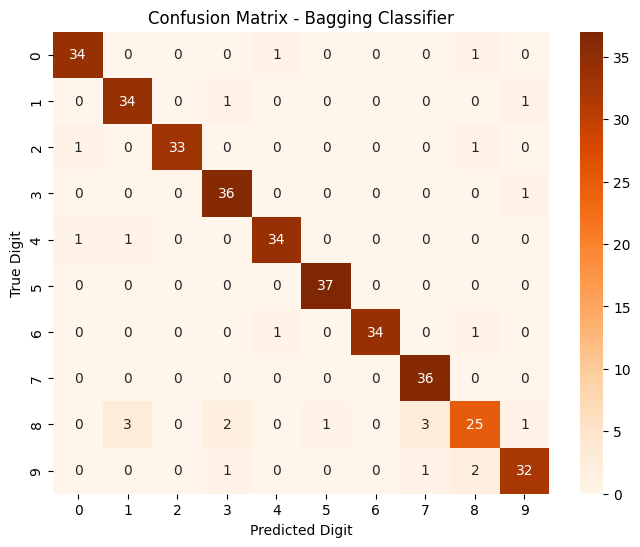

,Model,Best n_estimators,Best CV Accuracy,Test Accuracy,Macro F1-score
0,Bagging Classifier,150,0.945708,0.930556,0.928956


In [57]:
# Confusion matrix
bagging_conf_matrix = metrics.confusion_matrix(y_digits_test, y_digits_pred_bagging)

plt.figure(figsize=(8, 6))
sns.heatmap(
    bagging_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.title("Confusion Matrix - Bagging Classifier")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

# Compact result
bagging_result = pd.DataFrame({
    "Model": ["Bagging Classifier"],
    "Best n_estimators": [bagging_grid_search.best_params_["n_estimators"]],
    "Best CV Accuracy": [bagging_grid_search.best_score_],
    "Test Accuracy": [bagging_test_accuracy],
    "Macro F1-score": [bagging_macro_f1]
})

display(bagging_result)

* **Random Forest: Train a RandomForestClassifier. Use GridSearchCV to tune n_estimators
(50-300), max_depth (same as before), and max_features (sqrt, log2). Report best parameters, test accuracy, confusion matrix, and feature importance.**

In [58]:
# Random Forest Classifier - Digits Classification

RF_classifier = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

RF_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": list(range(1, 21)),
    "max_features": ["sqrt", "log2"]
}

RF_grid_search = GridSearchCV(
    estimator=RF_classifier,
    param_grid=RF_param_grid,
    scoring="accuracy",
    cv=bagging_cv,
    n_jobs=-1,
    return_train_score=True
)

In [59]:
RF_grid_search.fit(X_digits_train, y_digits_train)

best_RF_classifier = RF_grid_search.best_estimator_

print("Random Forest GridSearchCV completed successfully.")
print("Best parameters:", RF_grid_search.best_params_)
print("Best mean CV accuracy:", round(RF_grid_search.best_score_, 4))

Random Forest GridSearchCV completed successfully.
Best parameters: {'max_depth': 11, 'max_features': 'sqrt', 'n_estimators': 100}
Best mean CV accuracy: 0.9784


In [60]:
# evaluation
y_digits_pred_RF = best_RF_classifier.predict(X_digits_test)

RF_test_accuracy = metrics.accuracy_score(y_digits_test, y_digits_pred_RF)
RF_macro_f1 = metrics.f1_score(y_digits_test, y_digits_pred_RF, average="macro")

print("Random Forest test accuracy is:", round(RF_test_accuracy, 4))
print("Random Forest macro F1-score is:", round(RF_macro_f1, 4))

Random Forest test accuracy is: 0.9639
Random Forest macro F1-score is: 0.9634


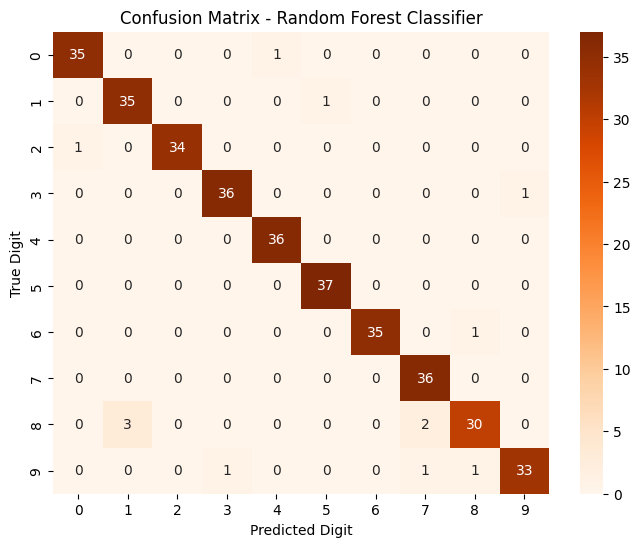

,Model,Best n_estimators,Best max_depth,Best max_features,Best CV Accuracy,Test Accuracy,Macro F1-score
0,Random Forest Classifier,100,11,sqrt,0.978429,0.963889,0.963391


In [61]:
# Confusion matrix
RF_conf_matrix = metrics.confusion_matrix(y_digits_test, y_digits_pred_RF)

plt.figure(figsize=(8, 6))
sns.heatmap(
    RF_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

# Best model summary
RF_result = pd.DataFrame({
    "Model": ["Random Forest Classifier"],
    "Best n_estimators": [RF_grid_search.best_params_["n_estimators"]],
    "Best max_depth": [RF_grid_search.best_params_["max_depth"]],
    "Best max_features": [RF_grid_search.best_params_["max_features"]],
    "Best CV Accuracy": [RF_grid_search.best_score_],
    "Test Accuracy": [RF_test_accuracy],
    "Macro F1-score": [RF_macro_f1]
})

display(RF_result)

,Feature Index,Pixel Row,Pixel Column,Importance
26,26,3,2,0.047011
36,36,4,4,0.044905
21,21,2,5,0.044444
43,43,5,3,0.039133
42,42,5,2,0.037673
28,28,3,4,0.033863
20,20,2,4,0.032124
38,38,4,6,0.029786
34,34,4,2,0.029376
10,10,1,2,0.028613


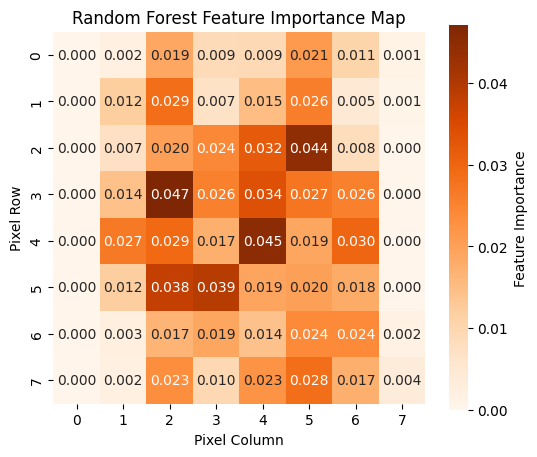

In [62]:
# Random Forest Feature Importance

RF_feature_importances = best_RF_classifier.feature_importances_

RF_feature_importance_df = pd.DataFrame({
    "Feature Index": np.arange(len(RF_feature_importances)),
    "Pixel Row": np.arange(len(RF_feature_importances)) // 8,
    "Pixel Column": np.arange(len(RF_feature_importances)) % 8,
    "Importance": RF_feature_importances
}).sort_values(by="Importance", ascending=False)

display(RF_feature_importance_df.head(15))

RF_importance_image = RF_feature_importances.reshape(8, 8)

plt.figure(figsize=(6, 5))
sns.heatmap(
    RF_importance_image,
    annot=True,
    fmt=".3f",
    cmap="Oranges",
    square=True,
    cbar_kws={"label": "Feature Importance"}
)

plt.title("Random Forest Feature Importance Map")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.show()

* **Create a bar chart comparing test accuracy of the single tree, bagging, and random forest.**

,Model,Test Accuracy,Macro F1-score
0,Single Decision Tree,0.850000,0.850841
1,Bagging Classifier,0.930556,0.928956
2,Random Forest,0.963889,0.963391


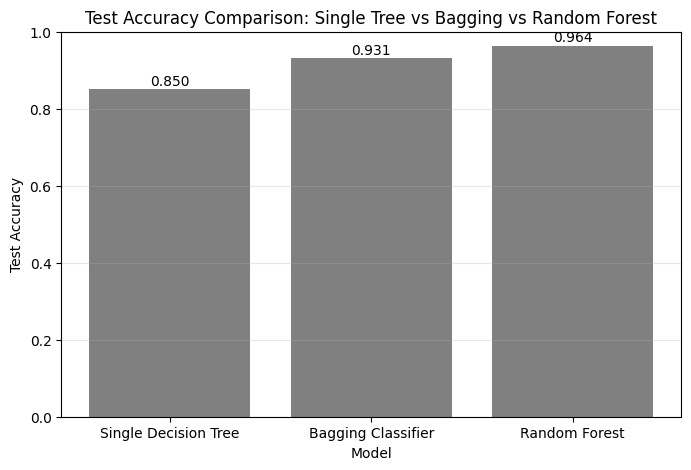

In [63]:
# Accuracy Comparison

if "DT_test_accuracy" not in globals():
    y_digits_pred_DT = best_DT_classifier.predict(X_digits_test)
    DT_test_accuracy = metrics.accuracy_score(y_digits_test, y_digits_pred_DT)
    DT_test_f1_macro = metrics.f1_score(y_digits_test, y_digits_pred_DT, average="macro")

part2a_accuracy_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Bagging Classifier",
        "Random Forest"
    ],
    "Test Accuracy": [
        DT_test_accuracy,
        bagging_test_accuracy,
        RF_test_accuracy
    ],
    "Macro F1-score": [
        DT_test_f1_macro,
        bagging_macro_f1,
        RF_macro_f1
    ]
})

display(part2a_accuracy_comparison)

plt.figure(figsize=(8, 5))

plt.bar(
    part2a_accuracy_comparison["Model"],
    part2a_accuracy_comparison["Test Accuracy"],
    color="gray"
)

plt.title("Test Accuracy Comparison: Single Tree vs Bagging vs Random Forest")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

for index, value in enumerate(part2a_accuracy_comparison["Test Accuracy"]):
    plt.text(
        index,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.show()

### Part 2a - Brief Interpretation

* **Bagging and Random Forest were compared with the best single Decision Tree from Part 1.**

* **Bagging improves stability by training several decision trees on bootstrap samples and averaging their predictions. Random Forest extends this idea by also selecting random subsets of features at each split, which usually reduces correlation between trees and improves generalization.**

* **The accuracy comparison shows whether ensemble methods improved over the single Decision Tree. The Random Forest feature importance map also indicates which pixel regions were most useful for recognizing handwritten digits.**

* **2b. Boosting - Digits Classification**

* **AdaBoost: Train an AdaBoostClassifier with a decision tree base. Tune n_estimators
and learning_rate (0.01, 0.1, 1.0). Report test metrics.**

In [64]:
# AdaBoost Classifier - Digits Classification

adaboost_base_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=RANDOM_STATE
)

# Compatibility with different scikit-learn versions
try:
    adaboost_classifier = AdaBoostClassifier(
        estimator=adaboost_base_tree,
        random_state=RANDOM_STATE
    )
except TypeError:
    adaboost_classifier = AdaBoostClassifier(
        base_estimator=adaboost_base_tree,
        random_state=RANDOM_STATE
    )

adaboost_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.1, 1.0]
}

adaboost_grid_search = GridSearchCV(
    estimator=adaboost_classifier,
    param_grid=adaboost_param_grid,
    scoring="accuracy",
    cv=bagging_cv,
    n_jobs=-1,
    return_train_score=True
)

adaboost_grid_search.fit(X_digits_train, y_digits_train)

best_adaboost_classifier = adaboost_grid_search.best_estimator_

print("AdaBoost GridSearchCV completed successfully.")
print("Best parameters:", adaboost_grid_search.best_params_)
print("Best mean CV accuracy is:", round(adaboost_grid_search.best_score_, 4))

AdaBoost GridSearchCV completed successfully.
Best parameters: {'learning_rate': 1.0, 'n_estimators': 200}
Best mean CV accuracy is: 0.8573


In [65]:
# prediction
y_digits_pred_adaboost = best_adaboost_classifier.predict(X_digits_test)

# metrics
adaboost_test_accuracy = metrics.accuracy_score(y_digits_test, y_digits_pred_adaboost)
adaboost_macro_precision = metrics.precision_score(y_digits_test, y_digits_pred_adaboost, average="macro", zero_division=0)
adaboost_macro_recall = metrics.recall_score(y_digits_test, y_digits_pred_adaboost, average="macro", zero_division=0)
adaboost_macro_f1 = metrics.f1_score(y_digits_test, y_digits_pred_adaboost, average="macro", zero_division=0)

adaboost_result = pd.DataFrame({
    "Model": ["AdaBoost Classifier"],
    "Best n_estimators": [adaboost_grid_search.best_params_["n_estimators"]],
    "Best learning_rate": [adaboost_grid_search.best_params_["learning_rate"]],
    "Best CV Accuracy": [adaboost_grid_search.best_score_],
    "Test Accuracy": [adaboost_test_accuracy],
    "Macro Precision": [adaboost_macro_precision],
    "Macro Recall": [adaboost_macro_recall],
    "Macro F1-score": [adaboost_macro_f1]
})

display(adaboost_result)

,Model,Best n_estimators,Best learning_rate,Best CV Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,AdaBoost Classifier,200,1.0,0.857346,0.863889,0.873935,0.863466,0.865207


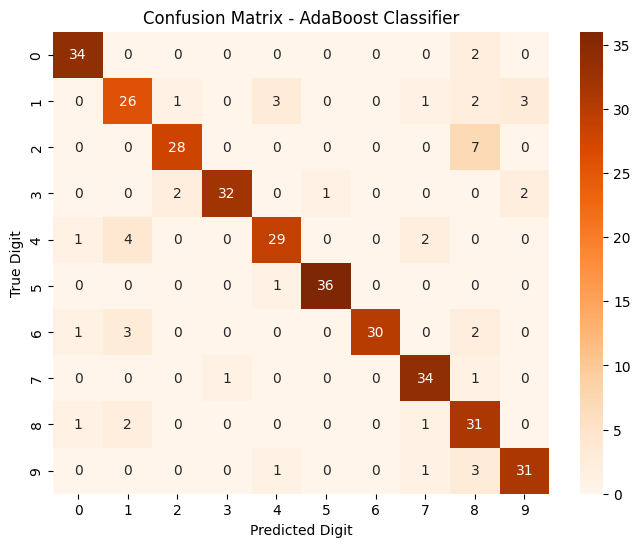

In [66]:
# Confusion matrix
adaboost_conf_matrix = metrics.confusion_matrix(y_digits_test, y_digits_pred_adaboost)

plt.figure(figsize=(8, 6))
sns.heatmap(
    adaboost_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.title("Confusion Matrix - AdaBoost Classifier")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

* **Gradient Boosting: Train a GradientBoostingClassifier. Tune n_estimators, learning_rate,
and max_depth (shallow trees, e.g., 1-5). Report test metrics.**

In [67]:
# Gradient Boosting Classifier - Digits Classification

GB_classifier = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)

# Hyperparameter grid
GB_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [1, 2, 3, 4, 5]
}

GB_grid_search = GridSearchCV(
    estimator=GB_classifier,
    param_grid=GB_param_grid,
    scoring="accuracy",
    cv=bagging_cv,
    n_jobs=-1,
    return_train_score=True
)

GB_grid_search.fit(X_digits_train, y_digits_train)

best_GB_classifier = GB_grid_search.best_estimator_

print("Gradient Boosting GridSearchCV completed successfully.")
print("Best parameters:", GB_grid_search.best_params_)
print("Best mean CV accuracy is:", round(GB_grid_search.best_score_, 4))

Gradient Boosting GridSearchCV completed successfully.
Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150}
Best mean CV accuracy is: 0.9694


In [68]:
# prediction
y_digits_pred_GB = best_GB_classifier.predict(X_digits_test)

# metrics
GB_test_accuracy = metrics.accuracy_score(y_digits_test, y_digits_pred_GB)
GB_macro_precision = metrics.precision_score(y_digits_test, y_digits_pred_GB, average="macro", zero_division=0)
GB_macro_recall = metrics.recall_score(y_digits_test, y_digits_pred_GB, average="macro", zero_division=0)
GB_macro_f1 = metrics.f1_score(y_digits_test, y_digits_pred_GB, average="macro", zero_division=0)

GB_result = pd.DataFrame({
    "Model": ["Gradient Boosting Classifier"],
    "Best n_estimators": [GB_grid_search.best_params_["n_estimators"]],
    "Best learning_rate": [GB_grid_search.best_params_["learning_rate"]],
    "Best max_depth": [GB_grid_search.best_params_["max_depth"]],
    "Best CV Accuracy": [GB_grid_search.best_score_],
    "Test Accuracy": [GB_test_accuracy],
    "Macro Precision": [GB_macro_precision],
    "Macro Recall": [GB_macro_recall],
    "Macro F1-score": [GB_macro_f1]
})

display(GB_result)

,Model,Best n_estimators,Best learning_rate,Best max_depth,Best CV Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,Gradient Boosting Classifier,150,0.1,2,0.969384,0.961111,0.960696,0.960794,0.960378


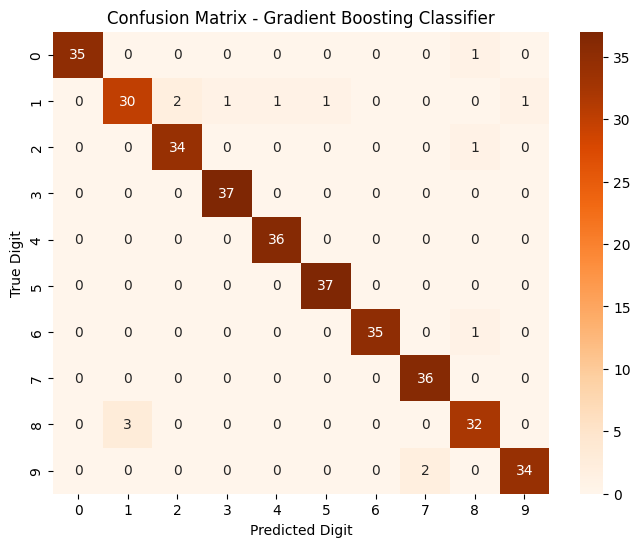

In [69]:
# Confusion matrix
GB_conf_matrix = metrics.confusion_matrix(y_digits_test, y_digits_pred_GB)

plt.figure(figsize=(8, 6))
sns.heatmap(
    GB_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.title("Confusion Matrix - Gradient Boosting Classifier")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

In [70]:
# Boosting Learning Curves: CV Accuracy vs n_estimators

adaboost_cv_results = pd.DataFrame(adaboost_grid_search.cv_results_)
GB_cv_results = pd.DataFrame(GB_grid_search.cv_results_)

best_adaboost_lr = adaboost_grid_search.best_params_["learning_rate"]

adaboost_curve = adaboost_cv_results[
    adaboost_cv_results["param_learning_rate"] == best_adaboost_lr
].copy()

adaboost_curve["param_n_estimators"] = adaboost_curve["param_n_estimators"].astype(int)
adaboost_curve = adaboost_curve.sort_values("param_n_estimators")


best_GB_lr = GB_grid_search.best_params_["learning_rate"]
best_GB_depth = GB_grid_search.best_params_["max_depth"]

GB_curve = GB_cv_results[
    (GB_cv_results["param_learning_rate"] == best_GB_lr) &
    (GB_cv_results["param_max_depth"] == best_GB_depth)
].copy()

GB_curve["param_n_estimators"] = GB_curve["param_n_estimators"].astype(int)
GB_curve = GB_curve.sort_values("param_n_estimators")

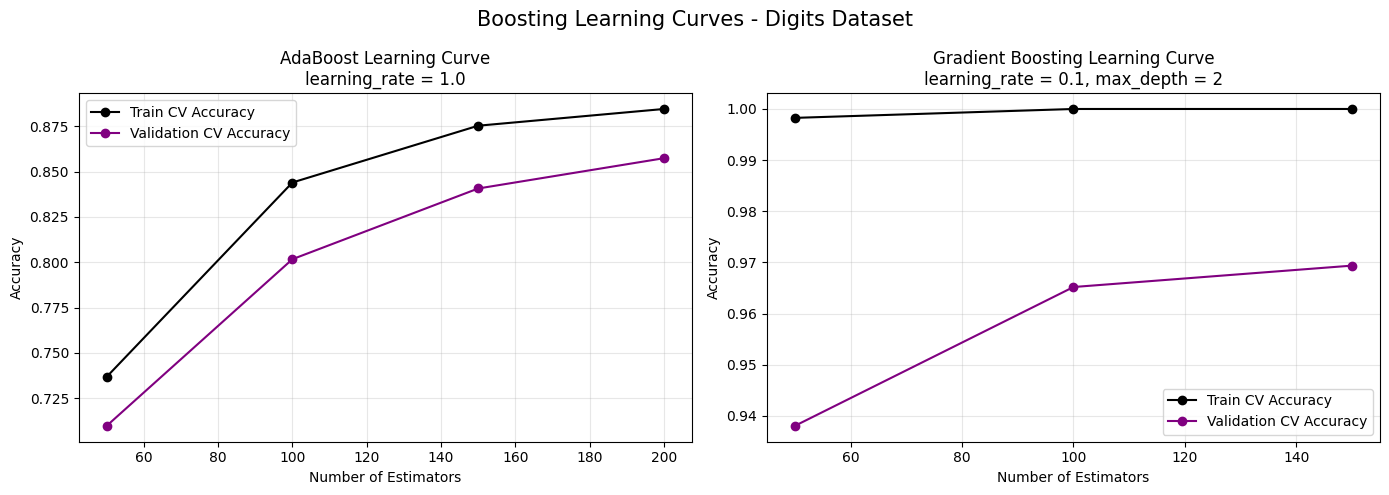

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AdaBoost curve
axes[0].plot(
    adaboost_curve["param_n_estimators"],
    adaboost_curve["mean_train_score"],
    marker="o",
    label="Train CV Accuracy",
    color='k'
)

axes[0].plot(
    adaboost_curve["param_n_estimators"],
    adaboost_curve["mean_test_score"],
    marker="o",
    label="Validation CV Accuracy",
    color='purple'
)

axes[0].set_title(f"AdaBoost Learning Curve\nlearning_rate = {best_adaboost_lr}")
axes[0].set_xlabel("Number of Estimators")
axes[0].set_ylabel("Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()


# Gradient Boosting curve
axes[1].plot(
    GB_curve["param_n_estimators"],
    GB_curve["mean_train_score"],
    marker="o",
    label="Train CV Accuracy",
    color='k'
)

axes[1].plot(
    GB_curve["param_n_estimators"],
    GB_curve["mean_test_score"],
    marker="o",
    label="Validation CV Accuracy",
    color='purple'
)

axes[1].set_title(
    f"Gradient Boosting Learning Curve\nlearning_rate = {best_GB_lr}, max_depth = {best_GB_depth}"
)
axes[1].set_xlabel("Number of Estimators")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle("Boosting Learning Curves - Digits Dataset", fontsize=15)
plt.tight_layout()
plt.show()

* **Collect all classification results (single tree, bagging, RF, AdaBoost, GB) in a performance
table (accuracy, macro F1). Discuss which ensemble dominates and why.**

In [72]:
# Classification Performance Comparison

classification_performance_table = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Bagging Classifier",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting"
    ],
    "Test Accuracy": [
        DT_test_accuracy,
        bagging_test_accuracy,
        RF_test_accuracy,
        adaboost_test_accuracy,
        GB_test_accuracy
    ],
    "Macro F1-score": [
        DT_test_f1_macro,
        bagging_macro_f1,
        RF_macro_f1,
        adaboost_macro_f1,
        GB_macro_f1
    ]
})

classification_performance_table = classification_performance_table.sort_values(
    by="Macro F1-score",
    ascending=False
).reset_index(drop=True)

display(classification_performance_table)

,Model,Test Accuracy,Macro F1-score
0,Random Forest,0.963889,0.963391
1,Gradient Boosting,0.961111,0.960378
2,Bagging Classifier,0.930556,0.928956
3,AdaBoost,0.863889,0.865207
4,Single Decision Tree,0.850000,0.850841


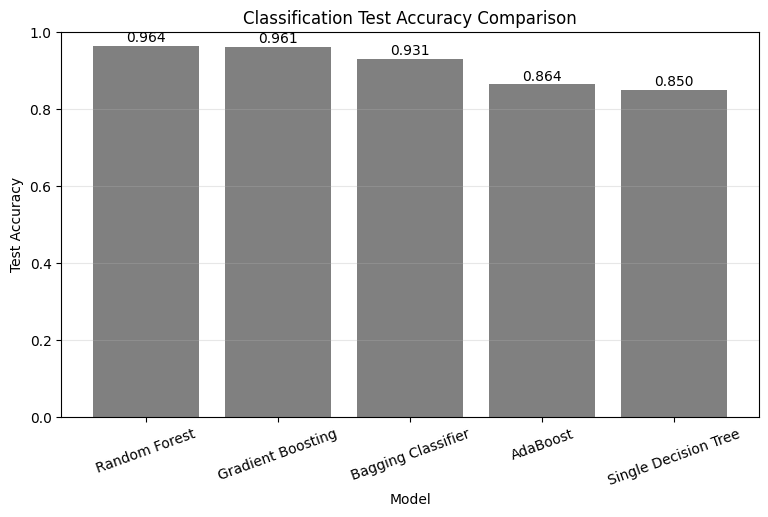

Best classification model based on Macro F1-score is:
Model             Random Forest
Test Accuracy          0.963889
Macro F1-score         0.963391
Name: 0, dtype: object


In [73]:
# Accuracy comparison
plt.figure(figsize=(9, 5))

plt.bar(
    classification_performance_table["Model"],
    classification_performance_table["Test Accuracy"],
    color="gray"
)

plt.title("Classification Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for index, value in enumerate(classification_performance_table["Test Accuracy"]):
    plt.text(
        index,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.show()

best_classification_model = classification_performance_table.iloc[0]

print("Best classification model based on Macro F1-score is:")
print(best_classification_model)

### Part 2b - Brief Interpretation

* **The classification results compare the single Decision Tree with Bagging, Random Forest, AdaBoost, and Gradient Boosting.**

* **Bagging and Random Forest mainly reduce variance by combining several decision trees.  
Boosting methods build trees sequentially and try to correct previous errors.**

* **The best model can be identified from the final table using test accuracy and macro F1-score.**
* **If Random Forest or Gradient Boosting performs best, it suggests that combining multiple trees improves generalization compared with a single Decision Tree.**

* **2c. Ensemble Regression - Diabetes**

* **Train a RandomForestRegressor and a GradientBoostingRegressor on the Diabetes data.
Tune the same hyperparameters as above (adjust for regression).**

In [74]:
# Ensemble Regression Models - Diabetes Dataset

# Safety definitions
if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

if "CV_FOLDS" not in globals():
    CV_FOLDS = 5

ensemble_regression_cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

RF_regressor = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

RF_reg_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [2, 4, 6, 8, 10, None],
    "max_features": ["sqrt", "log2", 1.0]
}

In [75]:
RF_reg_grid_search = GridSearchCV(
    estimator=RF_regressor,
    param_grid=RF_reg_param_grid,
    scoring="neg_mean_squared_error",
    cv=ensemble_regression_cv,
    n_jobs=-1,
    return_train_score=True
)

RF_reg_grid_search.fit(X_diabetes_train_scaled, y_diabetes_train)

best_RF_regressor = RF_reg_grid_search.best_estimator_

print("Random Forest Regressor tuning completed.")
print("Best RF parameters:", RF_reg_grid_search.best_params_)
print("Best RF CV MSE is:", round(-RF_reg_grid_search.best_score_, 4))

Random Forest Regressor tuning completed.
Best RF parameters: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Best RF CV MSE is: 3330.0658


In [76]:
# Gradient Boosting Regressor

GB_regressor = GradientBoostingRegressor(
    random_state=RANDOM_STATE
)

GB_reg_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [1, 2, 3, 4, 5]
}

GB_reg_grid_search = GridSearchCV(
    estimator=GB_regressor,
    param_grid=GB_reg_param_grid,
    scoring="neg_mean_squared_error",
    cv=ensemble_regression_cv,
    n_jobs=-1,
    return_train_score=True
)

GB_reg_grid_search.fit(X_diabetes_train_scaled, y_diabetes_train)

best_GB_regressor = GB_reg_grid_search.best_estimator_

print("Gradient Boosting Regressor tuning completed.")
print("Best GB parameters:", GB_reg_grid_search.best_params_)
print("Best GB CV MSE is:", round(-GB_reg_grid_search.best_score_, 4))

Gradient Boosting Regressor tuning completed.
Best GB parameters: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 200}
Best GB CV MSE is: 3252.5314


* **Compare their test MSE and R2 with the single decision tree regressor.**

In [77]:
# Performance Comparison

y_diabetes_pred_RF_reg = best_RF_regressor.predict(X_diabetes_test_scaled)

RF_reg_test_MSE = metrics.mean_squared_error(y_diabetes_test, y_diabetes_pred_RF_reg)
RF_reg_test_RMSE = np.sqrt(RF_reg_test_MSE)
RF_reg_test_r2 = metrics.r2_score(y_diabetes_test, y_diabetes_pred_RF_reg)


y_diabetes_pred_gb_reg = best_GB_regressor.predict(X_diabetes_test_scaled)

GB_reg_test_MSE = metrics.mean_squared_error(y_diabetes_test, y_diabetes_pred_gb_reg)
GB_reg_test_RMSE = np.sqrt(GB_reg_test_MSE)
GB_reg_test_r2 = metrics.r2_score(y_diabetes_test, y_diabetes_pred_gb_reg)


ensemble_regression_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    "Test MSE": [
        DT_reg_test_MSE,
        RF_reg_test_MSE,
        GB_reg_test_MSE
    ],
    "Test RMSE": [
        DT_reg_test_RMSE,
        RF_reg_test_RMSE,
        GB_reg_test_RMSE
    ],
    "Test R2": [
        DT_reg_test_r2,
        RF_reg_test_r2,
        GB_reg_test_r2
    ]
})

ensemble_regression_comparison = ensemble_regression_comparison.sort_values(
    by="Test MSE",
    ascending=True
).reset_index(drop=True)

display(ensemble_regression_comparison)

,Model,Test MSE,Test RMSE,Test R2
0,Random Forest Regressor,2728.017249,52.230425,0.485100
1,Gradient Boosting Regressor,2774.591028,52.674387,0.476310
2,Single Decision Tree Regressor,3735.499618,61.118734,0.294943


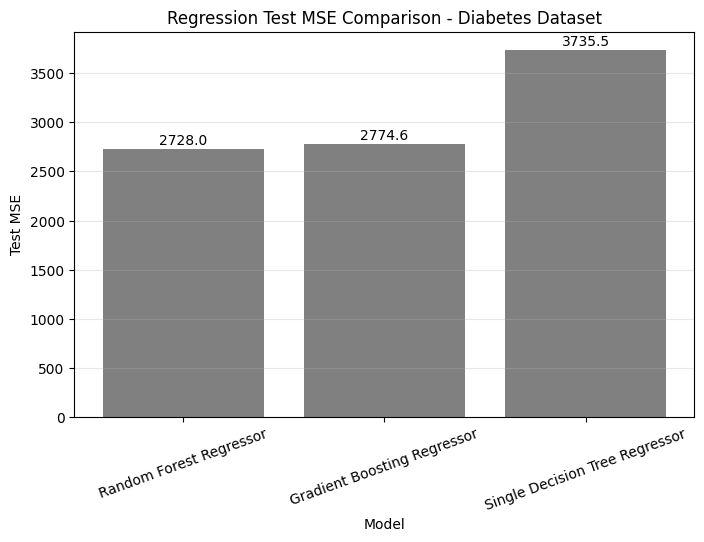

In [78]:
# MSE comparison

plt.figure(figsize=(8, 5))

plt.bar(
    ensemble_regression_comparison["Model"],
    ensemble_regression_comparison["Test MSE"],
    color="gray"
)

plt.title("Regression Test MSE Comparison - Diabetes Dataset")
plt.xlabel("Model")
plt.ylabel("Test MSE")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for index, value in enumerate(ensemble_regression_comparison["Test MSE"]):
    plt.text(
        index,
        value + 50,
        f"{value:.1f}",
        ha="center"
    )

plt.show()

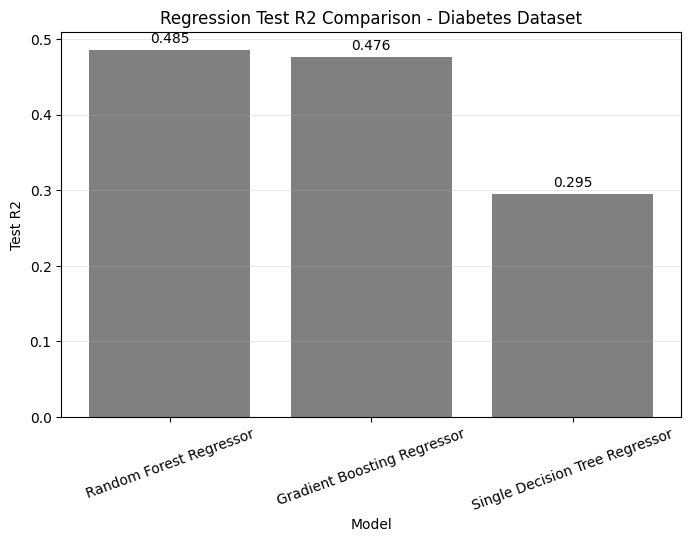

In [79]:

# R2 comparison

plt.figure(figsize=(8, 5))

plt.bar(
    ensemble_regression_comparison["Model"],
    ensemble_regression_comparison["Test R2"],
    color="gray"
)

plt.title("Regression Test R2 Comparison - Diabetes Dataset")
plt.xlabel("Model")
plt.ylabel("Test R2")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for index, value in enumerate(ensemble_regression_comparison["Test R2"]):
    plt.text(
        index,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.show()

* **Briefly comment on whether ensembles improve prediction of disease progression.**

In [80]:
# Brief Interpretation

best_regression_model = ensemble_regression_comparison.iloc[0]["Model"]
best_regression_MSE = ensemble_regression_comparison.iloc[0]["Test MSE"]
best_regression_r2 = ensemble_regression_comparison.iloc[0]["Test R2"]

single_tree_row = ensemble_regression_comparison[
    ensemble_regression_comparison["Model"] == "Single Decision Tree Regressor"
].iloc[0]

single_tree_mse = single_tree_row["Test MSE"]
single_tree_r2 = single_tree_row["Test R2"]

print("Best regression model is:", best_regression_model)
print("Best Test MSE is:", round(best_regression_MSE, 4))
print("Best Test R2 is:", round(best_regression_r2, 4))

print("*"*100)

if best_regression_MSE < single_tree_mse and best_regression_r2 > single_tree_r2:
    print("Interpretation:")
    print("The ensemble regression model improves prediction compared with the single Decision Tree.")
    print("It achieves lower test MSE and higher test R2, which indicates better generalization.")
elif best_regression_MSE < single_tree_mse:
    print("Interpretation:")
    print("The ensemble model reduces prediction error compared with the single Decision Tree.")
    print("However, the improvement in R2 should also be checked before making a strong conclusion.")
else:
    print("Interpretation:")
    print("The ensemble models do not clearly improve over the single Decision Tree on the test set.")
    print("This may indicate that the Diabetes regression task is noisy or difficult for tree-based models.")

Best regression model is: Random Forest Regressor
Best Test MSE is: 2728.0172
Best Test R2 is: 0.4851
****************************************************************************************************
Interpretation:
The ensemble regression model improves prediction compared with the single Decision Tree.
It achieves lower test MSE and higher test R2, which indicates better generalization.


### Part 2c - Brief Interpretation

* **Random Forest Regressor and Gradient Boosting Regressor were compared with the single Decision Tree Regressor on the Diabetes dataset.**

* **The comparison was based on *Test MSE*, *Test RMSE*, and Test R².**
* **A lower MSE/RMSE and a higher R² indicate better regression performance.**

* **If the ensemble models achieve lower test error and higher R² than the single tree, this means that combining multiple trees improves the prediction of disease progression.  
Random Forest mainly reduces variance by averaging many trees, while Gradient Boosting tries to reduce errors sequentially by adding weak learners.**

# 📌 Ensemble Methods – Key Results

### **1️⃣ Digits Classification**

* The single Decision Tree reached **0.850 test accuracy** and **0.851 macro F1-score**
* Bagging improved the result to **0.931 accuracy** and **0.929 macro F1-score**
* Random Forest achieved the best classification result with **0.964 accuracy** and **0.963 macro F1-score**
* Gradient Boosting was very close to Random Forest, with **0.961 accuracy** and **0.960 macro F1-score**
* AdaBoost improved over the single tree, but it was weaker than Bagging, Random Forest, and Gradient Boosting

### **2️⃣ Bagging and Random Forest**

* Bagging improved the single tree by averaging several decision trees trained on bootstrap samples
* Random Forest performed better because it also uses random feature selection at each split
* The Random Forest feature importance map shows that central stroke-related pixels were more useful than corner/background pixels
* This agrees with the structure of handwritten digit images, where most useful information is located around the middle pixels

### **3️⃣ Boosting Models**

* AdaBoost reached **0.864 test accuracy**, which was only a moderate improvement over the single tree
* Gradient Boosting performed much better, reaching **0.961 test accuracy**
* This shows that sequentially correcting model errors can be effective, especially when the weak learners are controlled with shallow trees

### **4️⃣ Diabetes Regression**

* The single Decision Tree Regressor had **Test MSE ≈ 3735.50** and **Test R² ≈ 0.295**
* Random Forest Regressor improved the result to **Test MSE ≈ 2728.02** and **Test R² ≈ 0.485**
* Gradient Boosting Regressor also improved performance with **Test MSE ≈ 2774.59** and **Test R² ≈ 0.476**
* Both ensemble regressors generalized better than the single Decision Tree

> 💡 **Takeaway:**
> Ensemble methods improved the performance in both classification and regression tasks. Random Forest was the strongest overall model, because it reduced the instability of individual decision trees and gave better generalization on both the Digits and Diabetes datasets.


<div class="alert alert-danger" role="alert"> 
🔎 Part 3: Clustering

* **3a. Data Preparation - Iris**

* **Load Iris (sklearn.datasets.load_iris). Keep the true labels only for external validation
after clustering.**

In [81]:
# Load Iris Dataset ----> we did this earlier at the beginning of the project.

iris = load_iris()

X_iris = iris.data
y_iris_true = iris.target

iris_feature_names = iris.feature_names
iris_target_names = iris.target_names

df_iris = pd.DataFrame(X_iris, columns=iris_feature_names)
df_iris["true_label"] = y_iris_true
df_iris["species"] = df_iris["true_label"].map(
    {i: name for i, name in enumerate(iris_target_names)}
)

print("Iris dataset loaded successfully.")
print("Feature matrix shape is:", X_iris.shape)
print("True label vector shape is:", y_iris_true.shape)
print("Feature names are:", iris_feature_names)
print("Species names are:", iris_target_names)

display(df_iris.head())

Iris dataset loaded successfully.
Feature matrix shape is: (150, 4)
True label vector shape is: (150,)
Feature names are: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Species names are: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),true_label,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


* **Standardize the features (essential for distance-based clustering).**

In [82]:
# Standardize Iris Features

iris_scaler = StandardScaler()

X_iris_scaled = iris_scaler.fit_transform(X_iris)

df_iris_scaled = pd.DataFrame(
    X_iris_scaled,
    columns=iris_feature_names
)

df_iris_scaled["true_label"] = y_iris_true
df_iris_scaled["species"] = df_iris["species"]

print("Feature standardization completed successfully.")
print(f"Mean of scaled features are: {np.round(X_iris_scaled.mean(axis=0), 4)}")
print(f"Standard deviation of scaled features are: {np.round(X_iris_scaled.std(axis=0), 4)}")

display(df_iris_scaled.head())

Feature standardization completed successfully.
Mean of scaled features are: [-0. -0. -0. -0.]
Standard deviation of scaled features are: [1. 1. 1. 1.]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),true_label,species
0,-0.900681,1.019004,-1.340227,-1.315444,0,setosa
1,-1.143017,-0.131979,-1.340227,-1.315444,0,setosa
2,-1.385353,0.328414,-1.397064,-1.315444,0,setosa
3,-1.506521,0.098217,-1.283389,-1.315444,0,setosa
4,-1.021849,1.249201,-1.340227,-1.315444,0,setosa


* **Perform a pairs plot colored by true species to visualize natural grouping.**

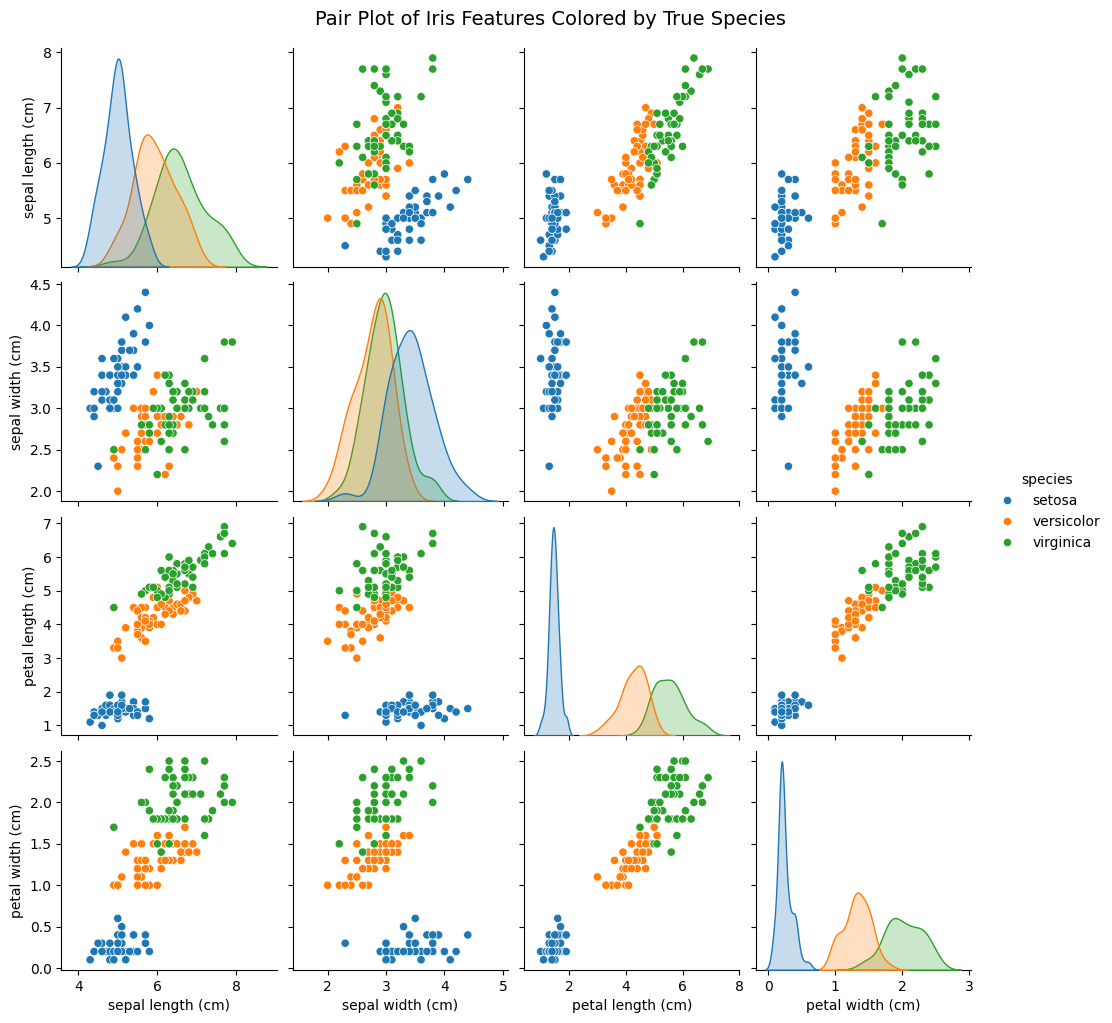

In [83]:
# Pair Plot Colored by True Species

sns.pairplot(
    df_iris,
    vars=iris_feature_names,
    hue="species",
    diag_kind="kde",
    corner=False
)

plt.suptitle(
    "Pair Plot of Iris Features Colored by True Species",
    y=1.02,
    fontsize=14
)

plt.show()

### Part 3a - Brief Interpretation

* **The Iris dataset was loaded with 150 samples and 4 numerical features.**
* **The true species labels were kept only for visualization and later external validation, not for fitting clustering models.**

* **The features were standardized because clustering methods such as K-Means and hierarchical clustering are distance-based and can be affected by different feature scales.**

* **The pair plot shows that *setosa* is clearly separated from the other two species, while *versicolor* and *virginica* have more overlap. This suggests that clustering may recover one class easily, but separating the other two classes may be more challenging.**

* **3b. K-Means Clustering**

* **Run KMeans for k = 1 to 10. Plot the inertia (elbow method) and silhouette score vs. k to
identify the optimal number of clusters.**

In [84]:
# K-Means for k = 1 to 10

k_values = range(1, 11)

kmeans_inertias = []
kmeans_silhouette_scores = []

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    kmeans_labels_temp = kmeans_model.fit_predict(X_iris_scaled)
    kmeans_inertias.append(kmeans_model.inertia_)
    
    # Silhouette score is only defined when k >= 2
    if k >= 2:
        sil_score = metrics.silhouette_score(X_iris_scaled, kmeans_labels_temp)
        kmeans_silhouette_scores.append(sil_score)
    else:
        kmeans_silhouette_scores.append(np.nan)

kmeans_k_selection_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": kmeans_inertias,
    "Silhouette Score": kmeans_silhouette_scores
})

display(kmeans_k_selection_df)

,k,Inertia,Silhouette Score
0,1,600.000000,NaN
1,2,222.361705,0.581750
2,3,139.820496,0.459948
3,4,114.092547,0.386941
4,5,90.927514,0.345901
5,6,81.544391,0.317079
6,7,72.631144,0.320197
7,8,62.540606,0.338692
8,9,55.119493,0.342360
9,10,47.391035,0.351793


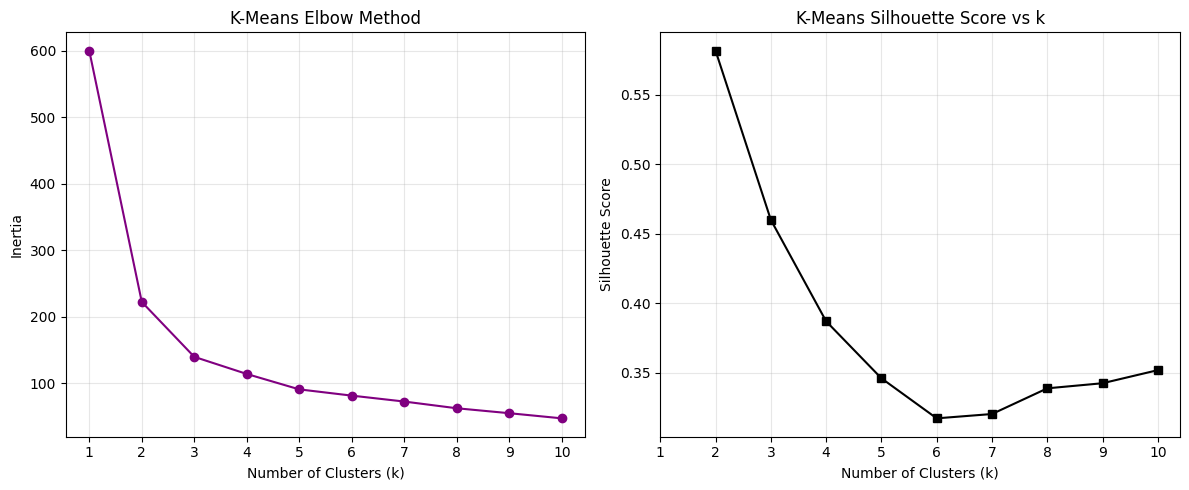

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    kmeans_k_selection_df["k"],
    kmeans_k_selection_df["Inertia"],
    marker="o",
    color="purple"
)
axes[0].set_title("K-Means Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

# Silhouette score plot
axes[1].plot(
    kmeans_k_selection_df["k"],
    kmeans_k_selection_df["Silhouette Score"],
    marker="s",
    color="k"
)
axes[1].set_title("K-Means Silhouette Score vs k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

* **Select k = 3 (matching the known species). Fit a final K-means model, obtain cluster labels.**

In [86]:
# Final K-Means Model with k = 3

kmeans_final = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_iris_scaled)

df_iris_scaled["KMeans_Cluster"] = kmeans_labels

print("Final K-Means model fitted successfully.")
print("Selected number of clusters: k = 3")
print(f"Cluster labels are: {np.unique(kmeans_labels)}")

kmeans_cluster_counts = pd.DataFrame({
    "Cluster": np.unique(kmeans_labels),
    "Number of Samples": pd.Series(kmeans_labels).value_counts().sort_index().values
})

display(kmeans_cluster_counts)

Final K-Means model fitted successfully.
Selected number of clusters: k = 3
Cluster labels are: [0 1 2]


,Cluster,Number of Samples
0,0,53
1,1,50
2,2,47


* **Visualize clusters in the first two principal components (apply PCA for 2D projection, not
for reduction, just for plotting).**

In [87]:
# K-Means Visualization in PCA Space

iris_pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_iris_pca_2d = iris_pca_2d.fit_transform(X_iris_scaled)

df_iris_pca = pd.DataFrame({
    "PC1": X_iris_pca_2d[:, 0],
    "PC2": X_iris_pca_2d[:, 1],
    "True Species": df_iris_scaled["species"],
    "KMeans Cluster": kmeans_labels
})

print(f"Explained variance by PC1 and PC2 are: {np.round(iris_pca_2d.explained_variance_ratio_, 4)}")

Explained variance by PC1 and PC2 are: [0.7296 0.2285]


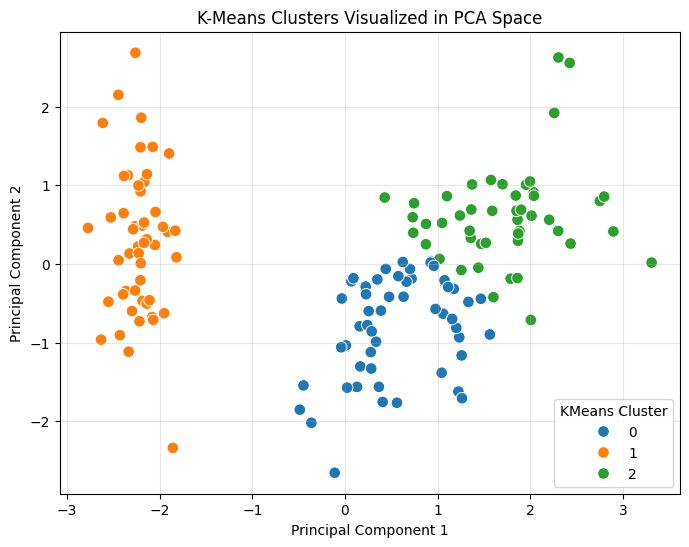

In [88]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_iris_pca,
    x="PC1",
    y="PC2",
    hue="KMeans Cluster",
    palette="tab10",
    s=70
)

plt.title("K-Means Clusters Visualized in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.show()

* **Compute internal metrics: Silhouette Score, Davies-Bouldin Index.**

In [89]:
# Internal Clustering Metrics

kmeans_silhouette = metrics.silhouette_score(X_iris_scaled, kmeans_labels)
kmeans_davies_bouldin = metrics.davies_bouldin_score(X_iris_scaled, kmeans_labels)

kmeans_internal_metrics = pd.DataFrame({
    "Method": ["K-Means"],
    "Silhouette Score": [kmeans_silhouette],
    "Davies-Bouldin Index": [kmeans_davies_bouldin]
})

display(kmeans_internal_metrics)

print("Silhouette Score is:", round(kmeans_silhouette, 4))
print("Davies-Bouldin Index is:", round(kmeans_davies_bouldin, 4))

,Method,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.459948,0.833595


Silhouette Score is: 0.4599
Davies-Bouldin Index is: 0.8336


* **Compute external metrics (using true labels): Adjusted Rand Index (ARI) and Normalized
Mutual Information (NMI).**

In [90]:
# External Clustering Metrics

kmeans_ari = metrics.adjusted_rand_score(y_iris_true, kmeans_labels)
kmeans_nmi = metrics.normalized_mutual_info_score(y_iris_true, kmeans_labels)

kmeans_external_metrics = pd.DataFrame({
    "Method": ["K-Means"],
    "Adjusted Rand Index (ARI)": [kmeans_ari],
    "Normalized Mutual Information (NMI)": [kmeans_nmi]
})

display(kmeans_external_metrics)

print(f"Adjusted Rand Index (ARI) is: {round(kmeans_ari, 4)}")
print(f"Normalized Mutual Information (NMI) is: {round(kmeans_nmi, 4)}")

,Method,Adjusted Rand Index (ARI),Normalized Mutual Information (NMI)
0,K-Means,0.620135,0.659487


Adjusted Rand Index (ARI) is: 0.6201
Normalized Mutual Information (NMI) is: 0.6595


### Part 3b - Brief Interpretation

* **K-Means was tested for `k = 1` to `10` using inertia and silhouette score.**
* **The elbow curve helps identify where adding more clusters gives smaller improvement, while the silhouette score measures how well-separated the clusters are.**

* **The final model was fitted with `k = 3`, matching the known number of Iris species.**
* **The clusters were visualized in the first two PCA components only for plotting.**

* **Internal metrics such as Silhouette Score and Davies-Bouldin Index evaluate cluster compactness and separation without using true labels.**
* **External metrics such as ARI and NMI compare the obtained clusters with the true Iris species labels, which are used only after clustering for validation.**

* **3c. Hierarchical Clustering**

* **Perform agglomerative hierarchical clustering with linkage=’ward’ (or complete/average).
Plot a dendrogram for the first 50 samples (to keep it readable).**

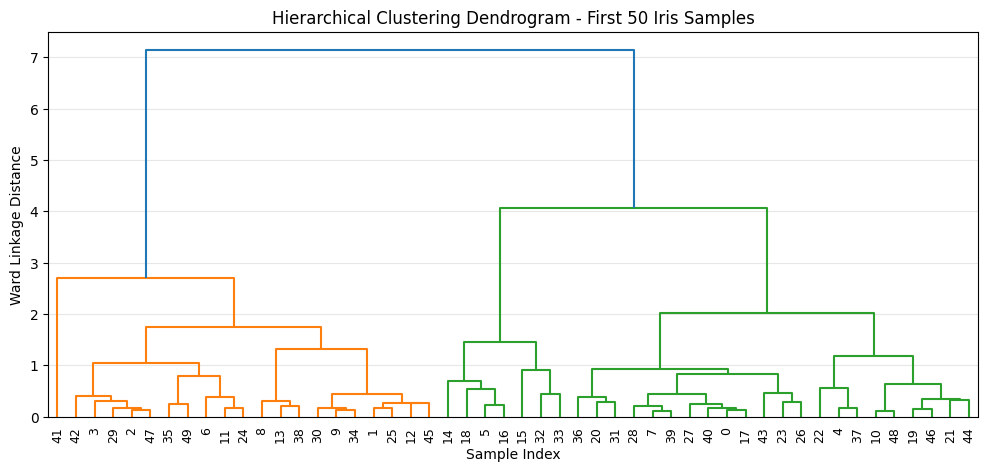

In [91]:
# Hierarchical Clustering Dendrogram

X_iris_scaled_first50 = X_iris_scaled[:50]

hierarchical_linkage_matrix = linkage(
    X_iris_scaled_first50,
    method="ward"
)

plt.figure(figsize=(12, 5))

# from scipy.cluster.hierarchy import linkage, dendrogram
dendrogram(
    hierarchical_linkage_matrix,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Hierarchical Clustering Dendrogram - First 50 Iris Samples")
plt.xlabel("Sample Index")
plt.ylabel("Ward Linkage Distance")
plt.grid(axis="y", alpha=0.3)

plt.show()

* **Cut the dendrogram at k = 3 and obtain cluster labels. Visualize in PCA space as above.**

In [92]:
# Agglomerative Clustering with k = 3

hierarchical_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_iris_scaled)

df_iris_scaled["Hierarchical_Cluster"] = hierarchical_labels
df_iris_pca["Hierarchical Cluster"] = hierarchical_labels

print("Agglomerative Hierarchical Clustering completed successfully.")
print("Selected number of clusters: k = 3")
print(f"Cluster labels are: {np.unique(hierarchical_labels)}")

hierarchical_cluster_counts = pd.DataFrame({
    "Cluster": np.unique(hierarchical_labels),
    "Number of Samples": pd.Series(hierarchical_labels).value_counts().sort_index().values
})

display(hierarchical_cluster_counts)

Agglomerative Hierarchical Clustering completed successfully.
Selected number of clusters: k = 3
Cluster labels are: [0 1 2]


,Cluster,Number of Samples
0,0,71
1,1,49
2,2,30


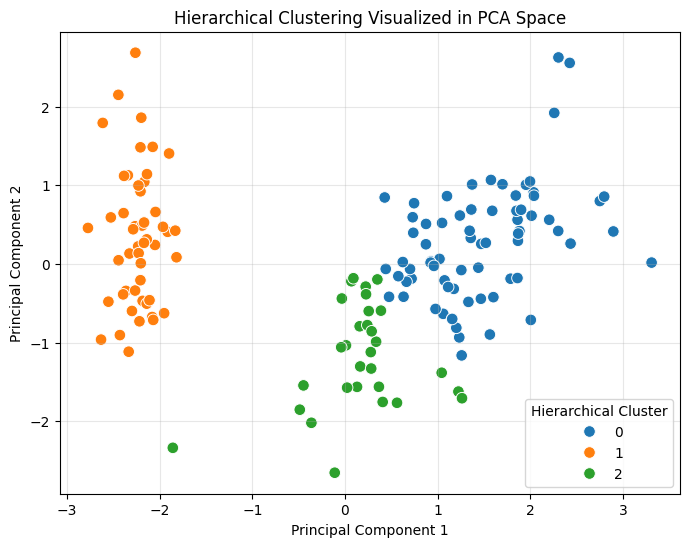

In [93]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_iris_pca,
    x="PC1",
    y="PC2",
    hue="Hierarchical Cluster",
    palette="tab10",
    s=70
)

plt.title("Hierarchical Clustering Visualized in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.show()

* **Compute the same internal and external metrics as for K-means.**

In [94]:
# Hierarchical Clustering Metrics

hierarchical_silhouette = metrics.silhouette_score(X_iris_scaled, hierarchical_labels)
hierarchical_davies_bouldin = metrics.davies_bouldin_score(X_iris_scaled, hierarchical_labels)

hierarchical_ari = metrics.adjusted_rand_score(y_iris_true, hierarchical_labels)
hierarchical_nmi = metrics.normalized_mutual_info_score(y_iris_true, hierarchical_labels)

hierarchical_metrics = pd.DataFrame({
    "Method": ["Hierarchical Clustering"],
    "Silhouette Score": [hierarchical_silhouette],
    "Davies-Bouldin Index": [hierarchical_davies_bouldin],
    "ARI": [hierarchical_ari],
    "NMI": [hierarchical_nmi]
})

display(hierarchical_metrics)

print(f"Silhouette Score is: {round(hierarchical_silhouette, 4)}")
print(f"Davies-Bouldin Index is: {round(hierarchical_davies_bouldin, 4)}")
print(f"Adjusted Rand Index (ARI) is: {round(hierarchical_ari, 4)}")
print(f"Normalized Mutual Information (NMI) is: {round(hierarchical_nmi, 4)}")

,Method,Silhouette Score,Davies-Bouldin Index,ARI,NMI
0,Hierarchical Clustering,0.446689,0.803467,0.615323,0.67547


Silhouette Score is: 0.4467
Davies-Bouldin Index is: 0.8035
Adjusted Rand Index (ARI) is: 0.6153
Normalized Mutual Information (NMI) is: 0.6755


### Part 3c - Brief Interpretation

* **Agglomerative hierarchical clustering was applied using Ward linkage.**
* **The dendrogram for the first 50 samples gives a readable view of how samples are merged step by step.**

* **The final clustering was cut at `k = 3`, matching the known number of Iris species.**
* **The PCA visualization shows how the hierarchical clusters are separated in two dimensions.**

* **The same internal and external metrics used for K-Means were computed here.**

* **3d. Gaussian Mixture Model (GMM)**

* **Fit GaussianMixture with k = 3 and covariance type ‘full‘ (if computationally feasible;
otherwise ‘tied‘ or ‘diag‘).**

In [95]:
# Gaussian Mixture Model with k = 3

GMM_model = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=RANDOM_STATE
)

GMM_labels = GMM_model.fit_predict(X_iris_scaled)

df_iris_scaled["GMM_Cluster"] = GMM_labels
df_iris_pca["GMM Cluster"] = GMM_labels

print("Gaussian Mixture Model fitted successfully.")
print("Number of components: k = 3")
print(f"Cluster labels: {np.unique(GMM_labels)}")

GMM_cluster_counts = pd.DataFrame({
    "Cluster": np.unique(GMM_labels),
    "Number of Samples": pd.Series(GMM_labels).value_counts().sort_index().values
})

display(GMM_cluster_counts)

Gaussian Mixture Model fitted successfully.
Number of components: k = 3
Cluster labels: [0 1 2]


,Cluster,Number of Samples
0,0,98
1,1,45
2,2,7


* **(Optional) Use AIC/BIC for k = 1 − 10 to confirm k = 3.**

In [96]:
# AIC and BIC for GMM Model Selection

GMM_k_values = range(1, 11)

GMM_aic_values = []
GMM_bic_values = []

for k in GMM_k_values:
    GMM_temp = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE
    )
    
    GMM_temp.fit(X_iris_scaled)
    
    GMM_aic_values.append(GMM_temp.aic(X_iris_scaled))
    GMM_bic_values.append(GMM_temp.bic(X_iris_scaled))

GMM_model_selection_df = pd.DataFrame({
    "k": list(GMM_k_values),
    "AIC": GMM_aic_values,
    "BIC": GMM_bic_values
})

display(GMM_model_selection_df)

,k,AIC,BIC
0,1,1008.520430,1050.669324
1,2,707.400579,794.709002
2,3,708.722596,841.190549
3,4,671.673396,849.300878
4,5,678.750720,901.537732
5,6,700.662026,968.608567
6,7,642.153129,955.259200
7,8,667.803683,1026.069283
8,9,725.926265,1129.351395
9,10,651.823334,1100.407993


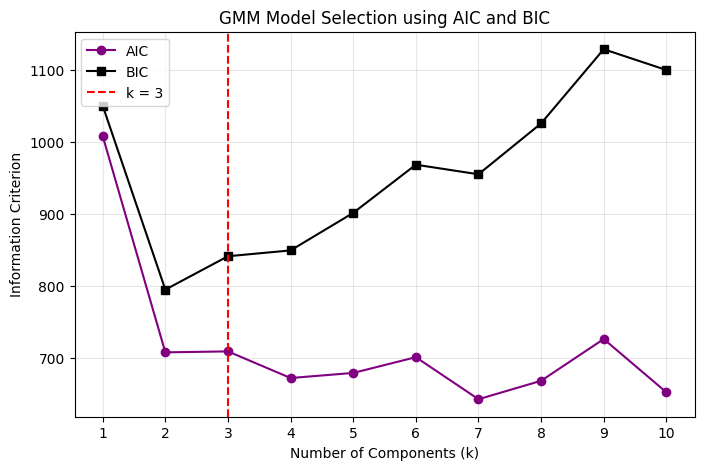

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    GMM_model_selection_df["k"],
    GMM_model_selection_df["AIC"],
    marker="o",
    label="AIC",
    color="purple"
)

plt.plot(
    GMM_model_selection_df["k"],
    GMM_model_selection_df["BIC"],
    marker="s",
    label="BIC",
    color="k"
)

plt.axvline(
    x=3,
    linestyle="--",
    label="k = 3",
    color='r'
)

plt.title("GMM Model Selection using AIC and BIC")
plt.xlabel("Number of Components (k)")
plt.ylabel("Information Criterion")
plt.xticks(list(GMM_k_values))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

* **Obtain cluster assignments and compute internal/external metrics.**

In [98]:
# GMM Clustering Metrics

GMM_silhouette = metrics.silhouette_score(X_iris_scaled, GMM_labels)
GMM_davies_bouldin = metrics.davies_bouldin_score(X_iris_scaled, GMM_labels)

GMM_ari = metrics.adjusted_rand_score(y_iris_true, GMM_labels)
GMM_nmi = metrics.normalized_mutual_info_score(y_iris_true, GMM_labels)

GMM_metrics = pd.DataFrame({
    "Method": ["Gaussian Mixture Model"],
    "Silhouette Score": [GMM_silhouette],
    "Davies-Bouldin Index": [GMM_davies_bouldin],
    "ARI": [GMM_ari],
    "NMI": [GMM_nmi]
})

display(GMM_metrics)

print("Silhouette Score is:", round(GMM_silhouette, 4))
print("Davies-Bouldin Index is:", round(GMM_davies_bouldin, 4))
print("Adjusted Rand Index (ARI) is:", round(GMM_ari, 4))
print("Normalized Mutual Information (NMI) is:", round(GMM_nmi, 4))

,Method,Silhouette Score,Davies-Bouldin Index,ARI,NMI
0,Gaussian Mixture Model,0.475143,0.886715,0.516459,0.657094


Silhouette Score is: 0.4751
Davies-Bouldin Index is: 0.8867
Adjusted Rand Index (ARI) is: 0.5165
Normalized Mutual Information (NMI) is: 0.6571


* **Plot the GMM cluster contours overlaid on the first two PCA components.**

In [99]:
# GMM Contours in PCA Space

GMM_pca_model = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=RANDOM_STATE
)

GMM_pca_labels = GMM_pca_model.fit_predict(X_iris_pca_2d)

x_min, x_max = X_iris_pca_2d[:, 0].min() - 1, X_iris_pca_2d[:, 0].max() + 1
y_min, y_max = X_iris_pca_2d[:, 1].min() - 1, X_iris_pca_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

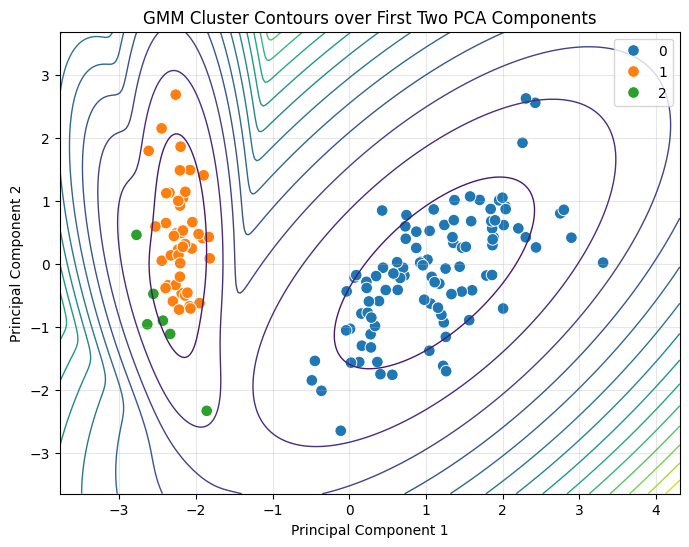

In [100]:
# Negative log likelihood for contour visualization
Z = -GMM_pca_model.score_samples(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contour(
    xx,
    yy,
    Z,
    levels=15,
    linewidths=1
)

sns.scatterplot(
    x=X_iris_pca_2d[:, 0],
    y=X_iris_pca_2d[:, 1],
    hue=GMM_pca_labels,
    palette="tab10",
    s=70
)

plt.title("GMM Cluster Contours over First Two PCA Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.show()

### Part 3d - Brief Interpretation

* **A Gaussian Mixture Model was fitted with `k = 3` and `covariance_type = full`.**
* **Unlike K-Means, GMM models each cluster as a Gaussian distribution and can represent elliptical cluster shapes.**

* **AIC and BIC were computed for `k = 1` to `10` as an optional check for the number of components.**
* **The final cluster labels were evaluated using the same internal and external metrics as K-Means and hierarchical clustering.**

* **The contour plot was drawn in the first two PCA components to visualize the probabilistic shape of the GMM clusters.**

* **3e. Clustering Comparison**

* **Present a table summarizing Silhouette, Davies-Bouldin, ARI, and NMI for K-means, hierarchical,
and GMM. Discuss which algorithm best recovers the true Iris species and why (e.g., assumptions
about cluster shape).**

In [101]:
# Clustering Comparison

clustering_comparison_table = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "Gaussian Mixture Model"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette,
        GMM_silhouette
    ],
    "Davies-Bouldin Index": [
        kmeans_davies_bouldin,
        hierarchical_davies_bouldin,
        GMM_davies_bouldin
    ],
    "ARI": [
        kmeans_ari,
        hierarchical_ari,
        GMM_ari
    ],
    "NMI": [
        kmeans_nmi,
        hierarchical_nmi,
        GMM_nmi
    ]
})

clustering_comparison_table_rounded = clustering_comparison_table.copy()

numeric_columns = [
    "Silhouette Score",
    "Davies-Bouldin Index",
    "ARI",
    "NMI"
]

clustering_comparison_table_rounded[numeric_columns] = (
    clustering_comparison_table_rounded[numeric_columns].round(4)
)

display(clustering_comparison_table_rounded)

,Algorithm,Silhouette Score,Davies-Bouldin Index,ARI,NMI
0,K-Means,0.4599,0.8336,0.6201,0.6595
1,Hierarchical Clustering,0.4467,0.8035,0.6153,0.6755
2,Gaussian Mixture Model,0.4751,0.8867,0.5165,0.6571


In [102]:
# Best models according to each metric
best_silhouette_model = clustering_comparison_table.loc[
    clustering_comparison_table["Silhouette Score"].idxmax()
]

best_davies_bouldin_model = clustering_comparison_table.loc[
    clustering_comparison_table["Davies-Bouldin Index"].idxmin()
]

best_ari_model = clustering_comparison_table.loc[
    clustering_comparison_table["ARI"].idxmax()
]

best_nmi_model = clustering_comparison_table.loc[
    clustering_comparison_table["NMI"].idxmax()
]

print("Best model based on Silhouette Score is:", best_silhouette_model["Algorithm"])
print("Best model based on Davies-Bouldin Index is:", best_davies_bouldin_model["Algorithm"])
print("Best model based on ARI is:", best_ari_model["Algorithm"])
print("Best model based on NMI is:", best_nmi_model["Algorithm"])

Best model based on Silhouette Score is: Gaussian Mixture Model
Best model based on Davies-Bouldin Index is: Hierarchical Clustering
Best model based on ARI is: K-Means
Best model based on NMI is: Hierarchical Clustering


# 📌 Clustering – Key Results

### **1️⃣ Data Preparation**

* Iris dataset has **150 samples** and **4 numerical features**
* Features were standardized because clustering methods depend on distances
* True labels were kept only for visualization and external validation
* Pair plot shows **setosa** is well separated, while **versicolor** and **virginica** overlap

### **2️⃣ K-Means**

* The elbow plot supports using around `k = 3`
* Final K-Means was fitted with `k = 3`
* It achieved **ARI = 0.6201** and **NMI = 0.6595**
* K-Means recovered the true species structure reasonably well

### **3️⃣ Hierarchical Clustering**

* Agglomerative clustering was applied using **Ward linkage**
* The dendrogram was plotted for the first 50 samples
* With `k = 3`, it achieved **ARI = 0.6153** and **NMI = 0.6755**
* Its performance was very close to K-Means

### **4️⃣ Gaussian Mixture Model**

* GMM was fitted with `k = 3` and `covariance_type = full`
* It achieved the best **Silhouette Score = 0.4751**
* However, its **ARI = 0.5165** was lower than K-Means and Hierarchical clustering
* This means its clusters were compact, but less aligned with the true species

### **5️⃣ Final Comparison**

* **K-Means** had the best ARI and recovered the true labels slightly better
* **Hierarchical clustering** had the best NMI and lowest Davies-Bouldin Index
* **GMM** gave flexible cluster shapes but weaker agreement with true labels

> 💡 **Takeaway:**
> K-Means and Hierarchical clustering performed best overall. Since Iris has one clearly separated class and two overlapping classes, perfect clustering is difficult, but both methods captured the main species structure reasonably well.

<div class="alert alert-danger" role="alert"> 
🔎 Part 4: Dimensionality Reduction

* **4a. Data Preparation - Digits**

* **The Digits dataset is already loaded; standardize the 64 features.**

In [103]:
# Standardize Digits Features

digits_scaler = StandardScaler()

X_digits_scaled = digits_scaler.fit_transform(X_digits)

df_digits_scaled = pd.DataFrame(
    X_digits_scaled,
    columns=digits_feature_names
)

print("Digits features standardized successfully.")
print(f"Original feature matrix shape is: {X_digits.shape}")
print(f"Scaled feature matrix shape is: {X_digits_scaled.shape}")

print(f"Mean of scaled features are: {np.round(X_digits_scaled.mean(axis=0)[:10], 4)}")

print(f"Standard deviation of scaled features are: {np.round(X_digits_scaled.std(axis=0)[:10], 4)}")

Digits features standardized successfully.
Original feature matrix shape is: (1797, 64)
Scaled feature matrix shape is: (1797, 64)
Mean of scaled features are: [ 0. -0. -0. -0.  0. -0. -0.  0. -0.  0.]
Standard deviation of scaled features are: [0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


* **Keep the digit labels for coloring but do not use them for fitting the transformations.**

In [104]:
# Keep Digit Labels for Coloring Only

digit_labels = y_digits.copy()

df_digits_reduction = pd.DataFrame({
    "digit_label": digit_labels,
    "digit_label_str": digit_labels.astype(str)
})

digit_label_counts = pd.DataFrame({
    "Digit": np.unique(digit_labels),
    "Number of Samples": pd.Series(digit_labels).value_counts().sort_index().values
})

print("Digit labels were kept only for visualization and later evaluation.")
print("Labels are not used for fitting PCA or t-SNE transformations.")

display(digit_label_counts)

Digit labels were kept only for visualization and later evaluation.
Labels are not used for fitting PCA or t-SNE transformations.


,Digit,Number of Samples
0,0,178
1,1,182
2,2,177
3,3,183
4,4,181
5,5,182
6,6,181
7,7,179
8,8,174
9,9,180


### Part 4a - Brief Interpretation

* **The Digits dataset was already loaded with 64 pixel-based features for each image.**
* **Before applying dimensionality reduction, the features were standardized so that all pixel features have comparable scale.**

* **The digit labels were kept only for coloring the plots and for later evaluation.**
* **They were not used when fitting PCA or t-SNE transformations.**

* **4b. PCA**

* **Apply PCA (do not specify n_components initially) and plot the cumulative explained variance
ratio versus number of components. Determine how many components capture 90% of the
variance.**

In [105]:
# PCA Explained Variance Analysis

PCA_full = PCA()

X_digits_PCA_full = PCA_full.fit_transform(X_digits_scaled)

PCA_explained_variance = PCA_full.explained_variance_ratio_
PCA_cumulative_variance = np.cumsum(PCA_explained_variance)

# Number of components needed to capture at least 90% of variance
n_components_90 = np.argmax(PCA_cumulative_variance >= 0.90) + 1

PCA_variance_df = pd.DataFrame({
    "Number of Components": np.arange(1, len(PCA_cumulative_variance) + 1),
    "Cumulative Explained Variance": PCA_cumulative_variance
})

display(PCA_variance_df.head(10))

print(f"Number of components needed to capture 90% variance are: {n_components_90}")
print(f"Cumulative explained variance at this point is: {round(PCA_cumulative_variance[n_components_90 - 1], 4)}")

,Number of Components,Cumulative Explained Variance
0,1,0.120339
1,2,0.215950
2,3,0.300394
3,4,0.365378
4,5,0.413979
5,6,0.456121
6,7,0.495542
7,8,0.529435
8,9,0.559418
9,10,0.588738


Number of components needed to capture 90% variance are: 31
Cumulative explained variance at this point is: 0.9005


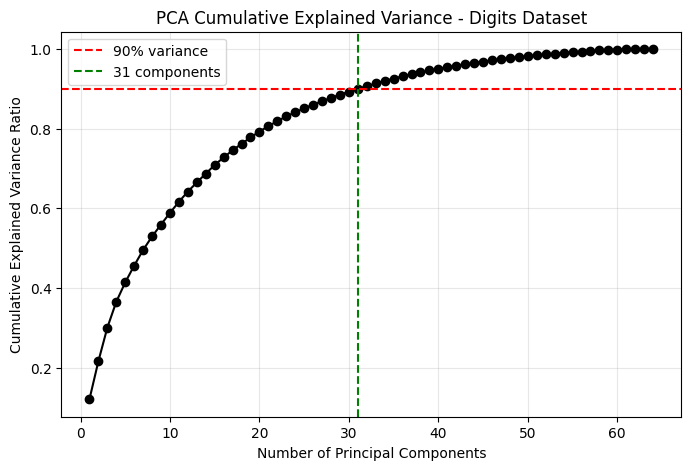

In [106]:
plt.figure(figsize=(8, 5))

plt.plot(
    PCA_variance_df["Number of Components"],
    PCA_variance_df["Cumulative Explained Variance"],
    marker="o",
    color="k"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% variance",
    color="r"
)

plt.axvline(
    x=n_components_90,
    linestyle="--",
    label=f"{n_components_90} components",
    color="g"
)

plt.title("PCA Cumulative Explained Variance - Digits Dataset")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

* **Project the data into 2 dimensions using PCA. Create a scatter plot where each digit is a
different color. Observe class separation.**

In [107]:
# 2D PCA Projection

PCA_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_digits_PCA_2d = PCA_2d.fit_transform(X_digits_scaled)

df_digits_PCA_2d = pd.DataFrame({
    "PC1": X_digits_PCA_2d[:, 0],
    "PC2": X_digits_PCA_2d[:, 1],
    "Digit": digit_labels,
    "Digit Label": digit_labels.astype(str)
})

print(f"Explained variance ratio by the first two principal components are: {np.round(PCA_2d.explained_variance_ratio_, 4)}")

print(f"Total explained variance by 2D PCA is: {round(np.sum(PCA_2d.explained_variance_ratio_), 4)}")

Explained variance ratio by the first two principal components are: [0.1203 0.0956]
Total explained variance by 2D PCA is: 0.2159


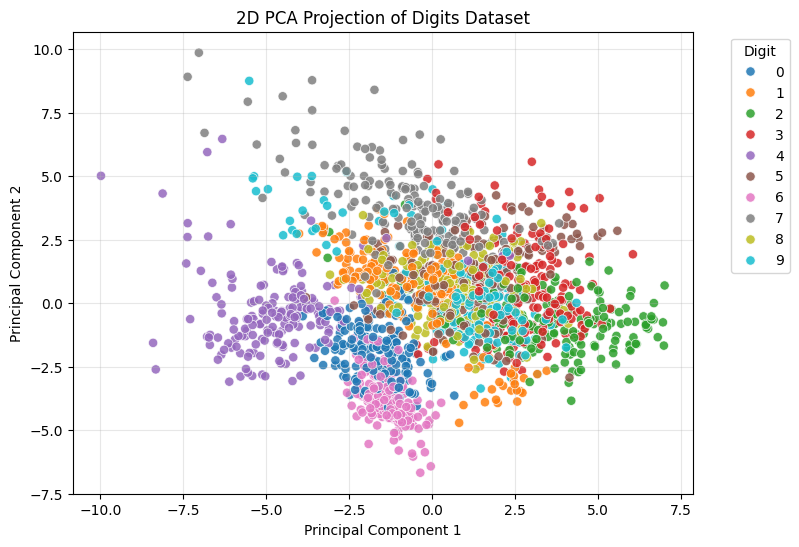

In [108]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_digits_PCA_2d,
    x="PC1",
    y="PC2",
    hue="Digit Label",
    palette="tab10",
    s=45,
    alpha=0.85
)

plt.title("2D PCA Projection of Digits Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Digit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.show()

* **Briefly comment on the linear nature of PCA and its limitations for this image data.**

In [109]:
# PCA Interpretation Summary

print("PCA Interpretation:")
print(f"- Number of components needed for 90% variance: {n_components_90}")
print(f"- Variance captured by first two components: {np.sum(PCA_2d.explained_variance_ratio_):.4f}")
print("- PCA is a linear dimensionality reduction method.")
print("- It finds directions with maximum variance, not necessarily directions with best class separation.")
print("- Therefore, some digit classes may overlap in the 2D PCA plot.")
print("- For image data, class structure can be nonlinear, so PCA may not fully separate all digits in two dimensions.")

PCA Interpretation:
- Number of components needed for 90% variance: 31
- Variance captured by first two components: 0.2159
- PCA is a linear dimensionality reduction method.
- It finds directions with maximum variance, not necessarily directions with best class separation.
- Therefore, some digit classes may overlap in the 2D PCA plot.
- For image data, class structure can be nonlinear, so PCA may not fully separate all digits in two dimensions.


### Part 4b - Brief Interpretation

* **PCA was first applied without specifying the number of components.**
* **The cumulative explained variance curve shows how many principal components are needed to preserve most of the information in the 64-dimensional Digits data.**

* **The number of components required to capture *90% of the variance* was computed from the cumulative explained variance ratio.**

* **The data was then projected into two dimensions using PCA.**
* **The 2D PCA scatter plot shows some visible class structure, but several digit classes still overlap.**

* **This is expected because PCA is a **linear** dimensionality reduction method.**

* **4c. t-SNE**

* **Apply TSNE (from sklearn.manifold) with n_components=2. Experiment with two different
perplexity values (e.g., 30 and 100) and a fixed random state. Note: t-SNE can be slow on
the full Digits set; you may use 1000 randomly selected samples or the entire set (1797 is still
manageable).**

In [110]:
# t-SNE with Perplexity = 30

tSNE_30 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto",
    max_iter=1000
)

X_digits_tSNE_30 = tSNE_30.fit_transform(X_digits_scaled)

df_digits_tSNE_30 = pd.DataFrame({
    "tSNE1": X_digits_tSNE_30[:, 0],
    "tSNE2": X_digits_tSNE_30[:, 1],
    "Digit": digit_labels,
    "Digit Label": digit_labels.astype(str)
})

print("t-SNE completed successfully with perplexity = 30")
print(f"t-SNE output shape is: {X_digits_tSNE_30.shape}")

display(df_digits_tSNE_30.head())

t-SNE completed successfully with perplexity = 30
t-SNE output shape is: (1797, 2)


,tSNE1,tSNE2,Digit,Digit Label
0,-38.777000,-30.429148,0,0
1,-15.336499,-2.788354,1,1
2,5.937756,-14.502025,2,2
3,28.006081,2.941233,3,3
4,-36.394794,2.617446,4,4


In [111]:
# t-SNE with Perplexity = 100

tSNE_100 = TSNE(
    n_components=2,
    perplexity=100,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto",
    max_iter=1000
)

X_digits_tSNE_100 = tSNE_100.fit_transform(X_digits_scaled)

df_digits_tSNE_100 = pd.DataFrame({
    "tSNE1": X_digits_tSNE_100[:, 0],
    "tSNE2": X_digits_tSNE_100[:, 1],
    "Digit": digit_labels,
    "Digit Label": digit_labels.astype(str)
})

print("t-SNE completed successfully with perplexity = 100")
print(f"t-SNE output shape is: {X_digits_tSNE_100.shape}")

display(df_digits_tSNE_100.head())

t-SNE completed successfully with perplexity = 100
t-SNE output shape is: (1797, 2)


,tSNE1,tSNE2,Digit,Digit Label
0,-21.816723,-19.240032,0,0
1,2.822846,-7.215151,1,1
2,-2.147716,-2.073437,2,2
3,7.237675,14.926394,3,3
4,-5.127347,-16.218012,4,4


* **Create 2D scatter plots for each perplexity, colored by digit. Compare the visual separation
with PCA.**

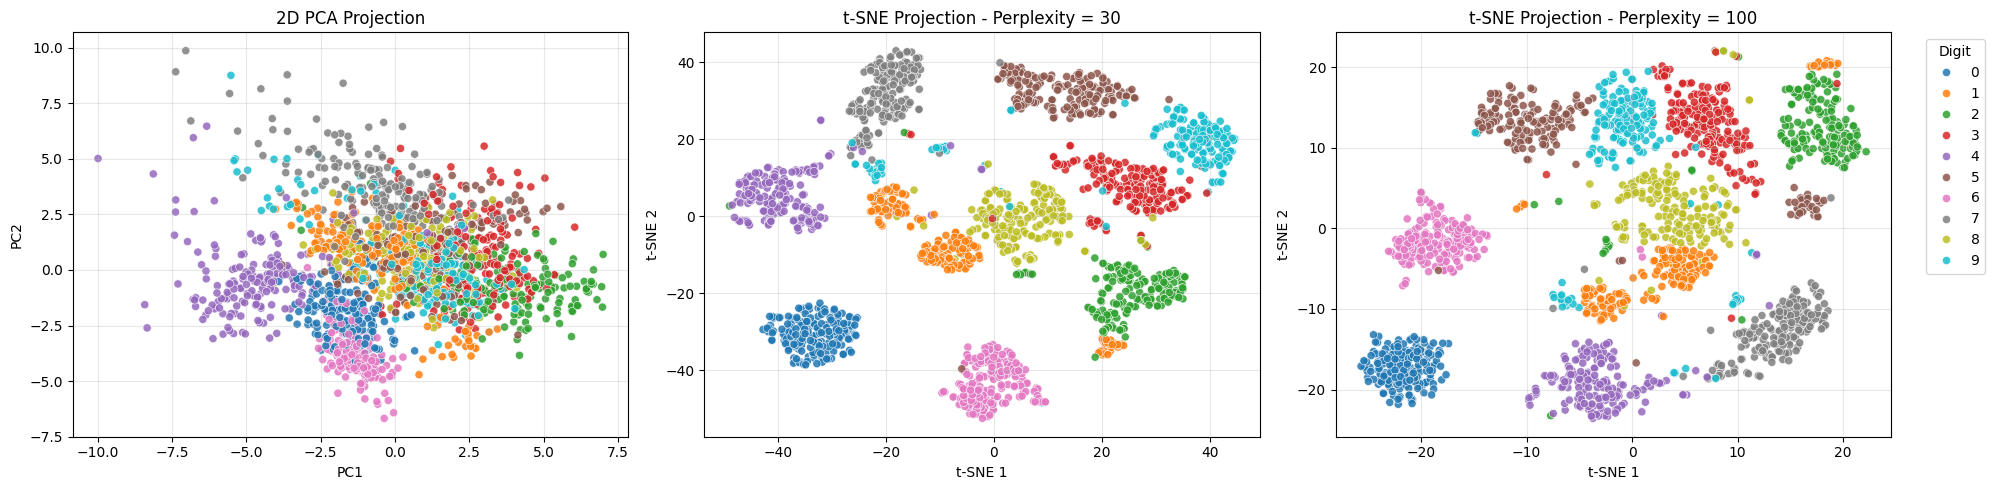

In [112]:
# PCA vs t-SNE Visual Comparison

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(
    x=X_digits_PCA_2d[:, 0],
    y=X_digits_PCA_2d[:, 1],
    hue=digit_labels.astype(str),
    palette="tab10",
    s=35,
    alpha=0.85,
    ax=axes[0],
    legend=False
)

axes[0].set_title("2D PCA Projection")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.3)


sns.scatterplot(
    data=df_digits_tSNE_30,
    x="tSNE1",
    y="tSNE2",
    hue="Digit Label",
    palette="tab10",
    s=35,
    alpha=0.85,
    ax=axes[1],
    legend=False
)

axes[1].set_title("t-SNE Projection - Perplexity = 30")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(alpha=0.3)


sns.scatterplot(
    data=df_digits_tSNE_100,
    x="tSNE1",
    y="tSNE2",
    hue="Digit Label",
    palette="tab10",
    s=35,
    alpha=0.85,
    ax=axes[2],
    legend=True
)

axes[2].set_title("t-SNE Projection - Perplexity = 100")
axes[2].set_xlabel("t-SNE 1")
axes[2].set_ylabel("t-SNE 2")
axes[2].legend(title="Digit", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

* **Discuss the role of perplexity, the non-linear embedding, and why t-SNE is not suited for
global structure preservation.**

### t-SNE Interpretation

* **t-SNE is a nonlinear dimensionality reduction method that is mainly designed for visualization.**
* **Unlike PCA, it can capture nonlinear relationships in the data and often separates handwritten digit classes more clearly in two dimensions.**

* **The `perplexity` parameter controls how many neighboring points are considered when building the embedding.**
* **A smaller perplexity, such as `30`, focuses more on local neighborhoods, while a larger perplexity, such as `100`, considers broader neighborhood structure.**

* **In the t-SNE plots, digit classes are usually more separated than in the PCA plot.**
* **However, t-SNE is not reliable for preserving global structure. The distances between far-away clusters and the relative positions of clusters should not be over-interpreted, because t-SNE mainly tries to preserve local similarities rather than global distances.**

* **4d. Quantitative Assessment (Optional but Encouraged)**

* **To measure how well the reduced representations preserve class information, train a simple
KNeighborsClassifier (k=5) on the 2D coordinates (train/test split 80/20) and report accuracy
for PCA and t-SNE. This gives a numeric complement to visual inspection.**

In [113]:
# Quantitative Assessment using KNN

def evaluate_2d_representation_with_KNN(representation_name, X_2d, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X_2d,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
    
    KNN_model = KNeighborsClassifier(n_neighbors=5)
    KNN_model.fit(X_train, y_train)
    
    y_pred = KNN_model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    
    return {
        "Representation": representation_name,
        "KNN Accuracy": accuracy
    }


KNN_PCA_result = evaluate_2d_representation_with_KNN(
    "PCA 2D",
    X_digits_PCA_2d,
    digit_labels
)

KNN_tSNE_30_result = evaluate_2d_representation_with_KNN(
    "t-SNE 2D - Perplexity 30",
    X_digits_tSNE_30,
    digit_labels
)

KNN_tSNE_100_result = evaluate_2d_representation_with_KNN(
    "t-SNE 2D - Perplexity 100",
    X_digits_tSNE_100,
    digit_labels
)

KNN_dimensionality_reduction_results = pd.DataFrame([
    KNN_PCA_result,
    KNN_tSNE_30_result,
    KNN_tSNE_100_result
])

KNN_dimensionality_reduction_results = (
    KNN_dimensionality_reduction_results
    .sort_values(by="KNN Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(KNN_dimensionality_reduction_results)

,Representation,KNN Accuracy
0,t-SNE 2D - Perplexity 30,0.966667
1,t-SNE 2D - Perplexity 100,0.947222
2,PCA 2D,0.527778


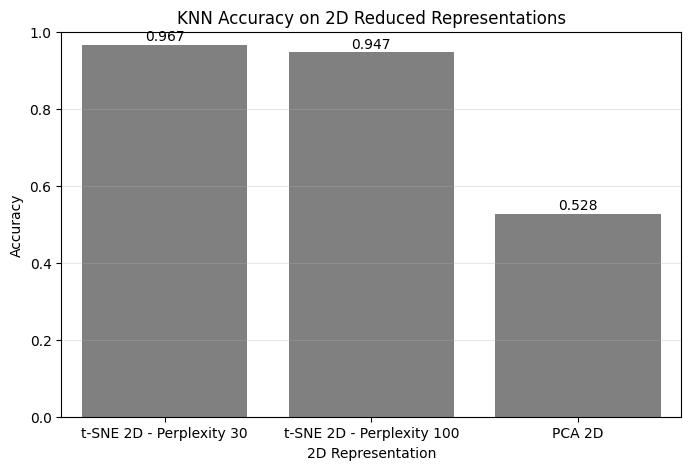

In [114]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=KNN_dimensionality_reduction_results,
    x="Representation",
    y="KNN Accuracy",
    color="gray"
)

plt.title("KNN Accuracy on 2D Reduced Representations")
plt.xlabel("2D Representation")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks()
plt.grid(axis="y", alpha=0.3)

for index, value in enumerate(KNN_dimensionality_reduction_results["KNN Accuracy"]):
    plt.text(
        index,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.show()

# 📌 Dimensionality Reduction – Key Results

### **1️⃣ Data Preparation**

* The Digits dataset contains **1797 samples** with **64 pixel features**
* The features were standardized before dimensionality reduction
* Digit labels were kept only for coloring the plots and evaluation, not for fitting PCA or t-SNE

### **2️⃣ PCA**

* PCA showed that **31 components** are needed to preserve about **90%** of the variance
* The first two PCA components captured only about **21.6%** of the total variance
* The 2D PCA plot showed some structure, but many digit classes overlapped
* This is expected because PCA is a **linear** method and does not directly optimize class separation

### **3️⃣ t-SNE**

* t-SNE was applied with two perplexity values: **30** and **100**
* Both t-SNE plots showed clearer local separation between digit classes compared with PCA
* Perplexity controls the neighborhood size considered by t-SNE
* t-SNE is nonlinear and good for visualization, but distances between far clusters should not be interpreted as reliable global structure

### **4️⃣ KNN Assessment**

* A KNN classifier with `k = 5` was trained on each 2D representation
* PCA 2D achieved **0.528 accuracy**
* t-SNE with perplexity 30 achieved **0.967 accuracy**
* t-SNE with perplexity 100 achieved **0.947 accuracy**

> 💡 **Takeaway:**
> t-SNE preserved local class neighborhoods much better than 2D PCA. PCA is useful for variance analysis, but for visual separation of handwritten digits, t-SNE produced a much clearer 2D representation.


<div class="alert alert-danger" role="alert"> 
🔎 Deliverables

# 📌 Comprehensive Discussion

### **1️⃣ Bias-Variance Trade-off in Tree Models**

Decision Trees are flexible models and can easily capture complex patterns in the data. However, if the tree becomes too deep, it may fit training-specific noise and suffer from high variance. This behavior was observed in the depth analysis, where deeper trees improved training performance but did not necessarily improve test performance.

Ensemble methods helped reduce this problem. For the Digits dataset, the single Decision Tree reached about **0.850 test accuracy**, while Bagging improved it to **0.931** and Random Forest reached **0.964**. In the Diabetes regression task, ensemble regressors also improved the test performance compared with the single Decision Tree. This shows that combining multiple trees can improve generalization and reduce overfitting.

### **2️⃣ Bagging / Random Forest vs Boosting**

Bagging and Random Forest mainly reduce variance. Bagging trains several trees on bootstrapped samples and averages their predictions. Random Forest improves this idea further by adding random feature selection, which makes the trees less correlated.

Boosting works differently. It builds models sequentially, where each new model focuses more on the errors of the previous models. Therefore, boosting is often useful for reducing bias. In the classification results, Gradient Boosting performed very well and reached about **0.961 test accuracy**, close to Random Forest. AdaBoost improved over the single tree but was weaker than Bagging, Random Forest, and Gradient Boosting in this experiment.

### **3️⃣ Clustering Algorithms and Their Limitations**

Clustering algorithms can fail when their assumptions do not match the actual data structure. For example, K-Means assumes compact and roughly spherical clusters. Therefore, it may perform poorly on non-spherical clusters, clusters with different densities, or heavily overlapping classes.

In the Iris clustering task, K-Means and Hierarchical clustering performed similarly. K-Means achieved the best **ARI**, while Hierarchical clustering achieved the best **NMI** and the lowest Davies-Bouldin Index. GMM is more flexible because it models clusters as Gaussian distributions and can represent elliptical shapes, but in this experiment its agreement with the true species labels was weaker than K-Means and Hierarchical clustering. This suggests that flexibility alone does not always guarantee better recovery of the true classes.

### **4️⃣ Interpretability vs Accuracy**

Single Decision Trees are easier to interpret because their decision rules and feature importances can be inspected directly. This is useful when understanding the model is important.

However, ensemble methods usually provide better predictive performance. In this project, Random Forest and Gradient Boosting clearly outperformed the single Decision Tree in classification, and ensemble regressors improved the Diabetes regression results as well. The trade-off is that ensembles are less transparent than a single tree, although feature importance can still provide some interpretability, especially for Random Forest.

### **5️⃣ PCA vs t-SNE**

PCA is a linear, fast, and interpretable dimensionality reduction method. It is useful for variance analysis and for understanding how much information can be preserved with fewer components. In the Digits dataset, **31 principal components** were needed to preserve about **90%** of the variance, while the first two components captured only about **21.6%**.

t-SNE is nonlinear and mainly useful for visualization. It produced much clearer 2D separation of digit classes than PCA. This was also supported by the KNN assessment, where PCA 2D achieved about **0.528 accuracy**, while t-SNE reached about **0.967** with perplexity 30 and **0.947** with perplexity 100.

However, t-SNE should not be used for interpreting global distances between clusters. Its objective is non-convex, results can depend on initialization and hyperparameters such as perplexity, and it mainly preserves local neighborhood structure rather than global geometry.

> 💡 **Final Takeaway:**
> Overall, ensemble methods improved the predictive performance of tree-based models by reducing variance and improving generalization. For clustering, algorithm assumptions strongly affected performance, especially when clusters overlapped. For dimensionality reduction, PCA was useful for fast and interpretable variance analysis, while t-SNE was more effective for visualizing local class separation in the Digits dataset.


In [115]:
# Armin Amani (404202215)